# Contour Frequency by Altitude Diagram

What altitude is the SLW occurring?

In [53]:
from netCDF4 import Dataset
import numpy as np
import os
import xarray as xr
import math
import pandas as pd
from collections import namedtuple
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.colors as mcolors
# import proplot as pplt

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [61]:
try:
    import IPython
    __file__ = IPython.extract_module_locals()[1]["__vsc_ipynb_file__"]
    root_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except (AttributeError, ImportError, KeyError):
    root_dir = os.path.abspath("../")

data_root = os.path.join(root_dir, 'data')
cfad_data_dir=os.path.join(data_root, 'ncfiles', 'cfad')
cfad_ar_data_dir=os.path.join(data_root, 'ncfiles', 'cfad_ar')
qhist_dir=os.path.join(root_dir, 'figures','qhist' )

## Plotting Function Definition

In [ ]:
def cfad(dataset, name, weird_colors=False):
    # fig = plt.figure(figsize=(7, 6))
    fig = plt.figure(figsize=(18.5, 10.5))

    df = pd.DataFrame({'LWC':dataset.lw_avg.values.flatten(), 'Z':dataset.Z_avg.values.flatten()}).dropna()
    
    if weird_colors:
        ax = plt.axes()
        fig.patch.set_facecolor('xkcd:mint green')
        ax.set_facecolor('xkcd:salmon')

    #ax = plt.hist2d(df.LWC, df.Z, bins=100, cmin=0.001, cmap='winter', norm=colors.LogNorm())
    ax = plt.hist2d(df.LWC, 
                    # df.Z, 
                    bins=(100, 50), cmin=0.2e-5, cmap="ice",norm=colors.LogNorm())
    # ax = plt.hist2d(df.LWC, df.Z, bins=200, cmin=0.001, cmap='viridis', norm=mcolors.PowerNorm(0.3))
    
    plt.title(f'Contour Frequency by Altitude Diagram\n{name}', fontsize=24)
    # plt.xlabel(r'Liquid Water Content $\left(\frac{g}{kg}\right)$')
    # plt.ylabel(r'Altitude $\left(meters\right)$')
    cbar = plt.colorbar(orientation="vertical")
    plt.xlim(0.00015, 0.002)
    plt.ylim(1000, 10000)
    plt.grid()

    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    

    plt.xlabel('Liquid Water Content g/kg', fontsize=20)
    plt.ylabel('Altitude (meters)', fontsize=20)
    #cbar = plt.colorbar(orientation="horizontal")

    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("Counts",size=16)
    # fig.patch.set_facecolor('gray')
    fig.patch.set_facecolor('white')
    return fig


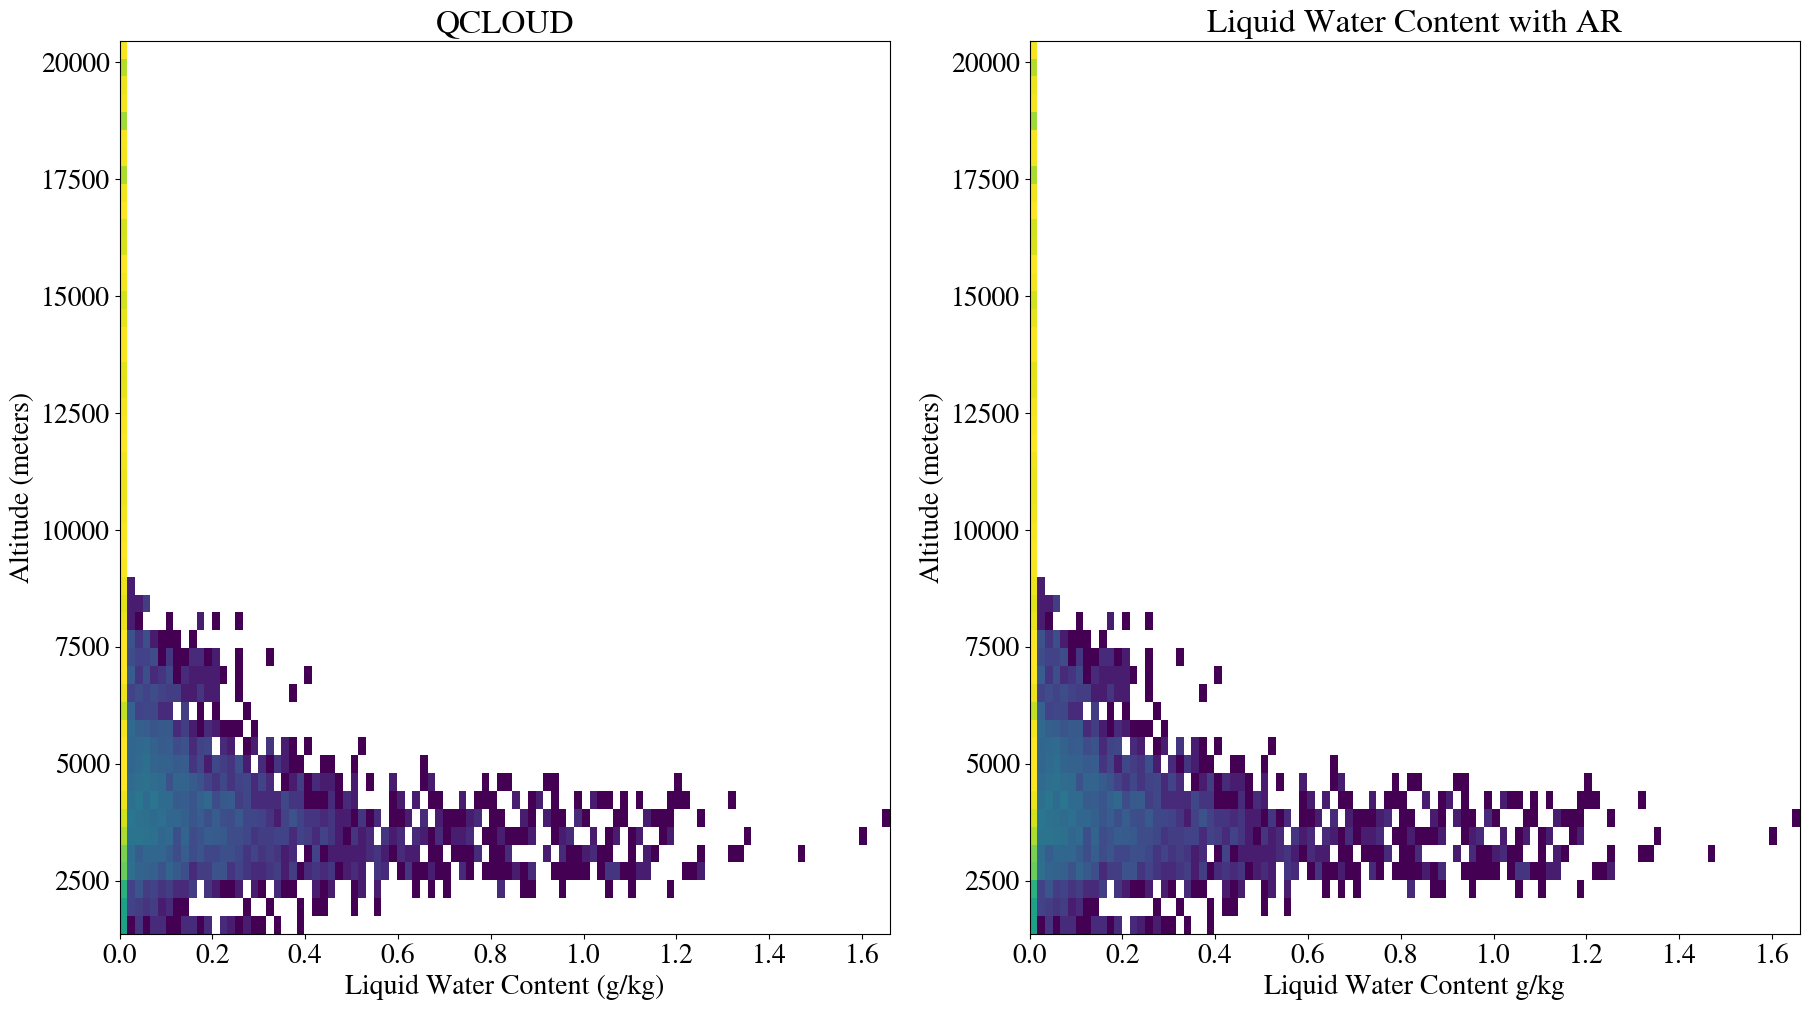

In [81]:
def plot_lw_ar_cfad(region):
    _file = os.path.join(cfad_ar_data_dir, f'lw_T_mask_{region}.nc')
    data=xr.open_dataset(_file)
    df = pd.DataFrame({
        'LW_AR':data.lw_ar.values.flatten(), 
        'LW':data.lw.values.flatten(), 
        'QCLOUD':data.QCLOUD_AR.values.flatten(), 
        'QICE':data.QICE_AR.values.flatten(), 
        'QSNOW':data.QSNOW_AR.values.flatten(), 
        'QRAIN':data.QRAIN_AR.values.flatten(),
        'QGRAUP':data.QGRAUP_AR.values.flatten(),
        'Z':data.Z.values.flatten()}).dropna()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18.5, 10.5))

    ax1.hist2d(
        df['QCLOUD']*1000, 
        df.Z, 
        bins=(100, 50), 
        cmin=0.2e-5, 
        norm=colors.LogNorm(),
        )
    # ax1.set_xlim(1e-6, 0.002)
    # ax1.set_ylim(1000, 10000)
    ax1.set_title('QCLOUD')
    ax1.set_xlabel('Liquid Water Content (g/kg)')
    ax1.set_ylabel('Altitude (meters)')

    # Plot data on the second subplot (right)
    ax2.hist2d(
        df['LW_AR']*1000, 
        df.Z, 
        bins=(100, 50), 
        cmin=0.2e-5, 
        norm=colors.LogNorm(),
        )
    # ax2.set_xlim(1e-6, 0.002)
    # ax2.set_ylim(1000, 10000)
    ax2.set_title('Liquid Water Content with AR')
    ax2.set_xlabel('Liquid Water Content g/kg')
    ax2.set_ylabel('Altitude (meters)')

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()
    plt.show()
    
for _region in ["BumpingRidge"]:#, "CayusePass", "BlewettPass", "BurntMountain", "CorralPass", "CougarMountain", "FishLake", "GrouseCamp", "MeadowsPass", "SasseRidge", "SkateCreek", "PotatoHill"]:
    plot_lw_ar_cfad(_region)

    


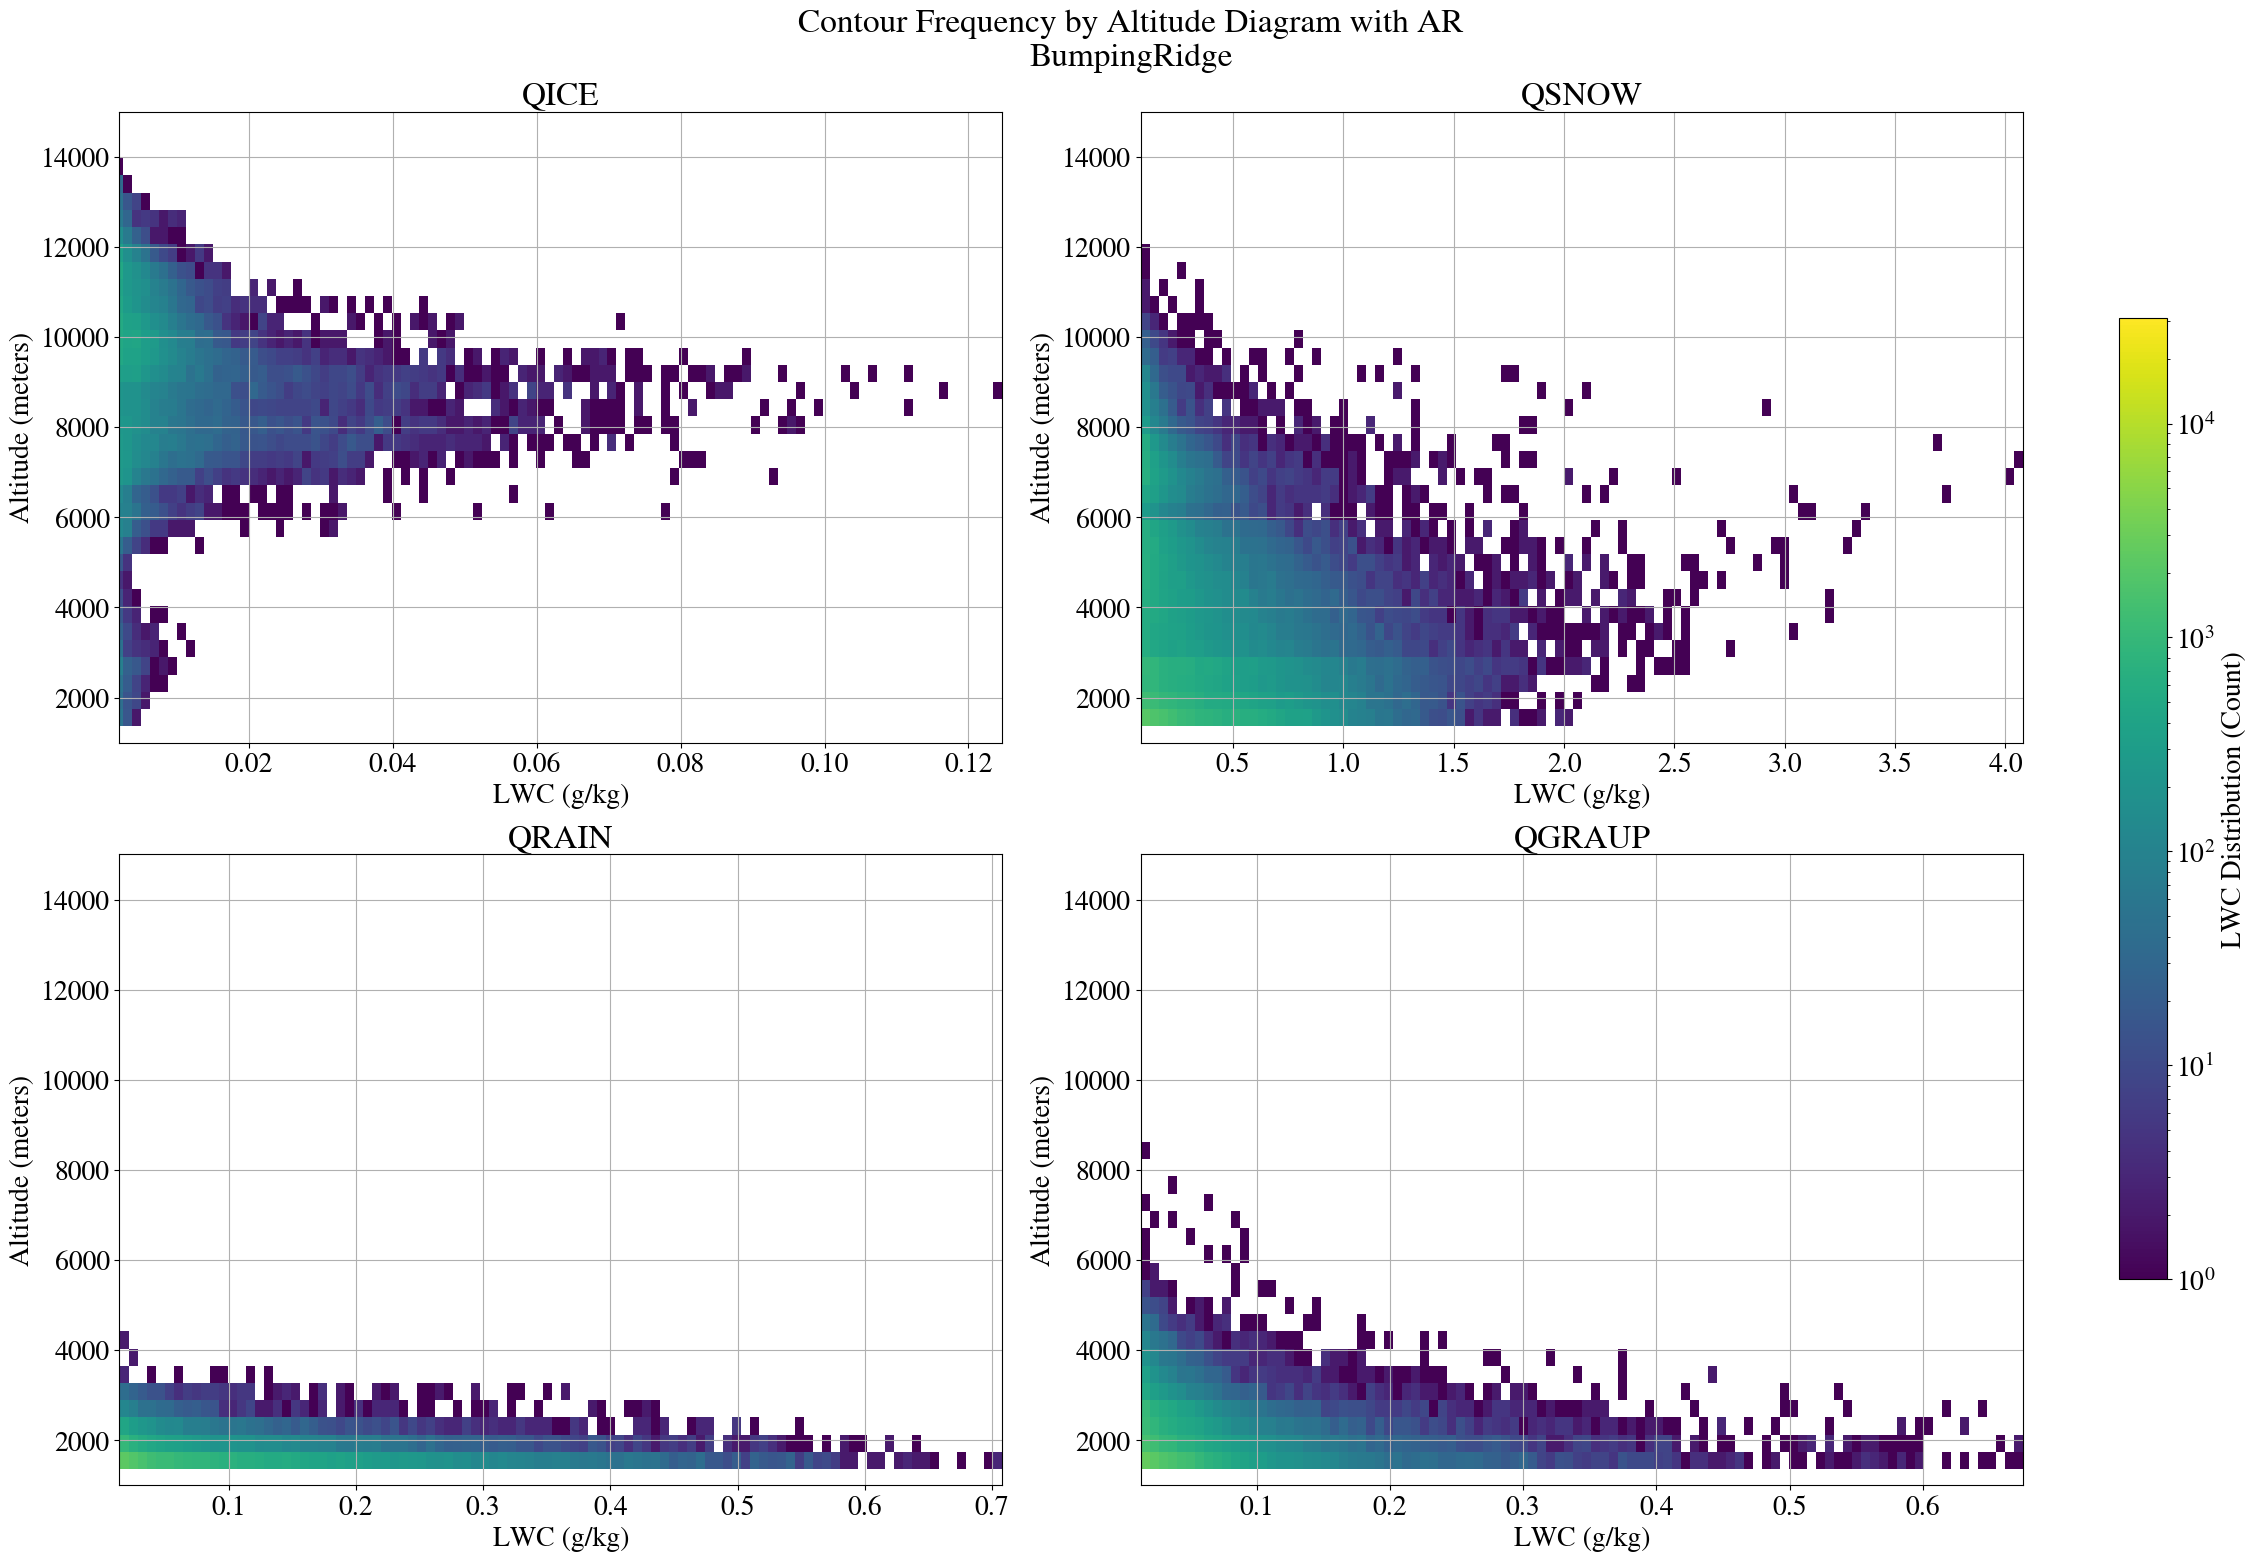

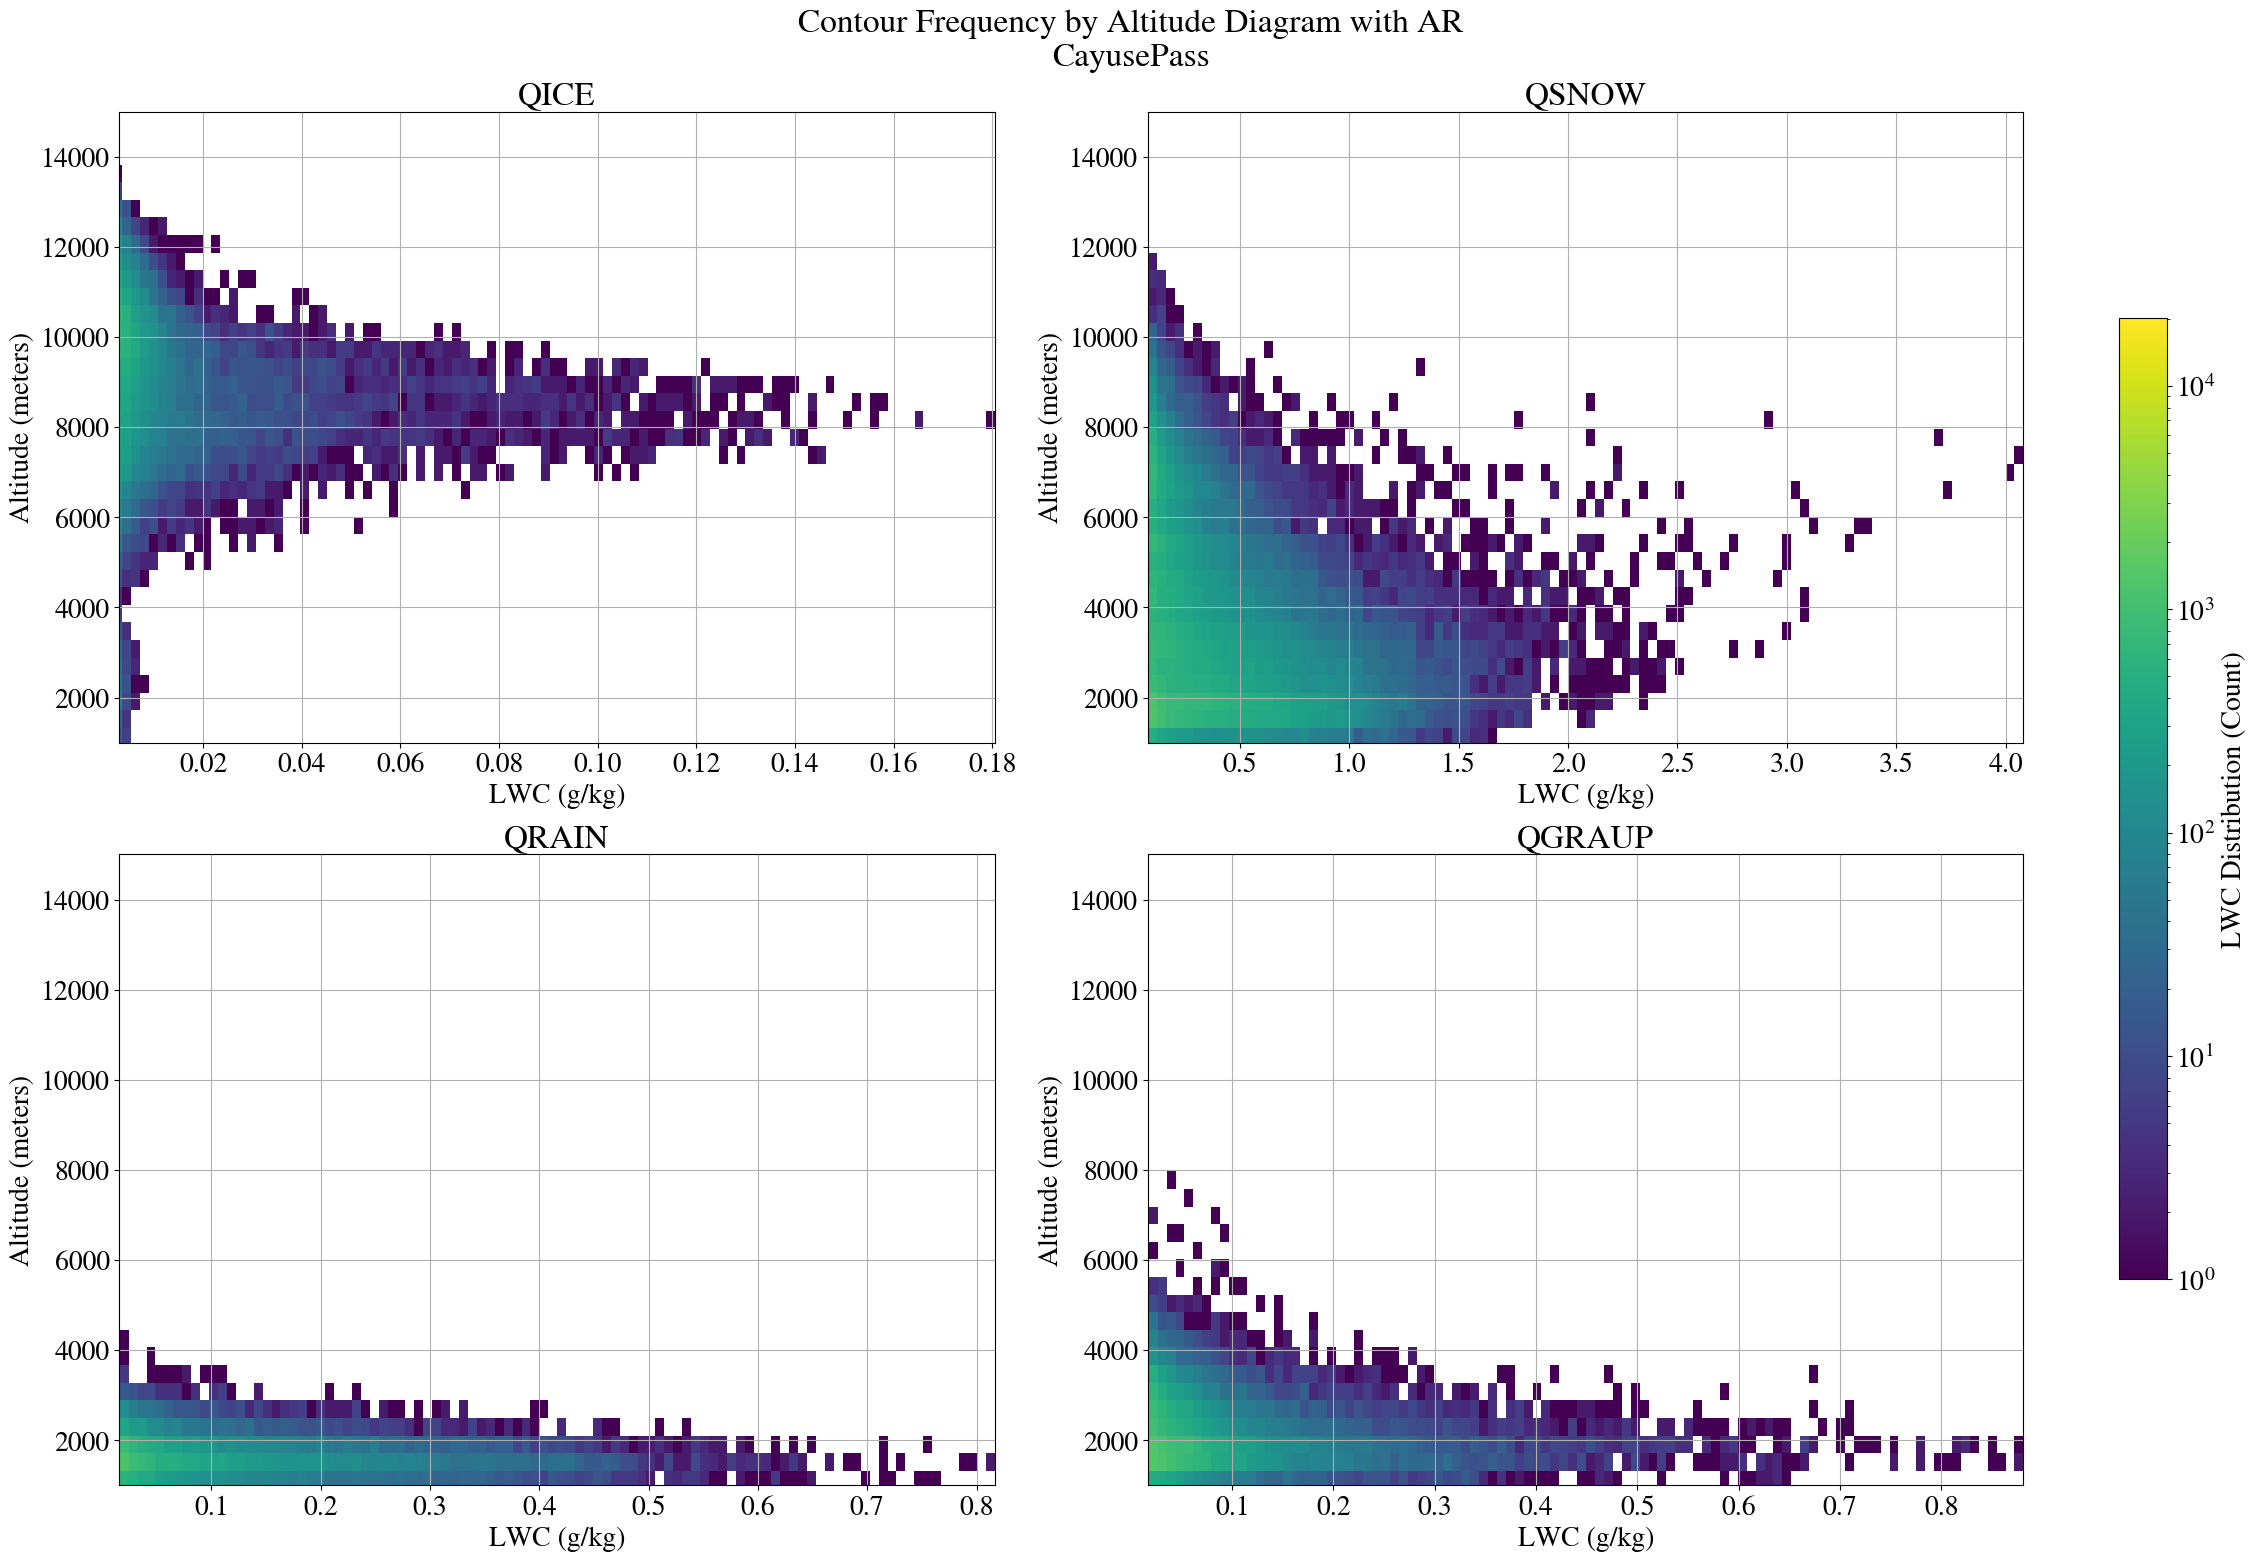

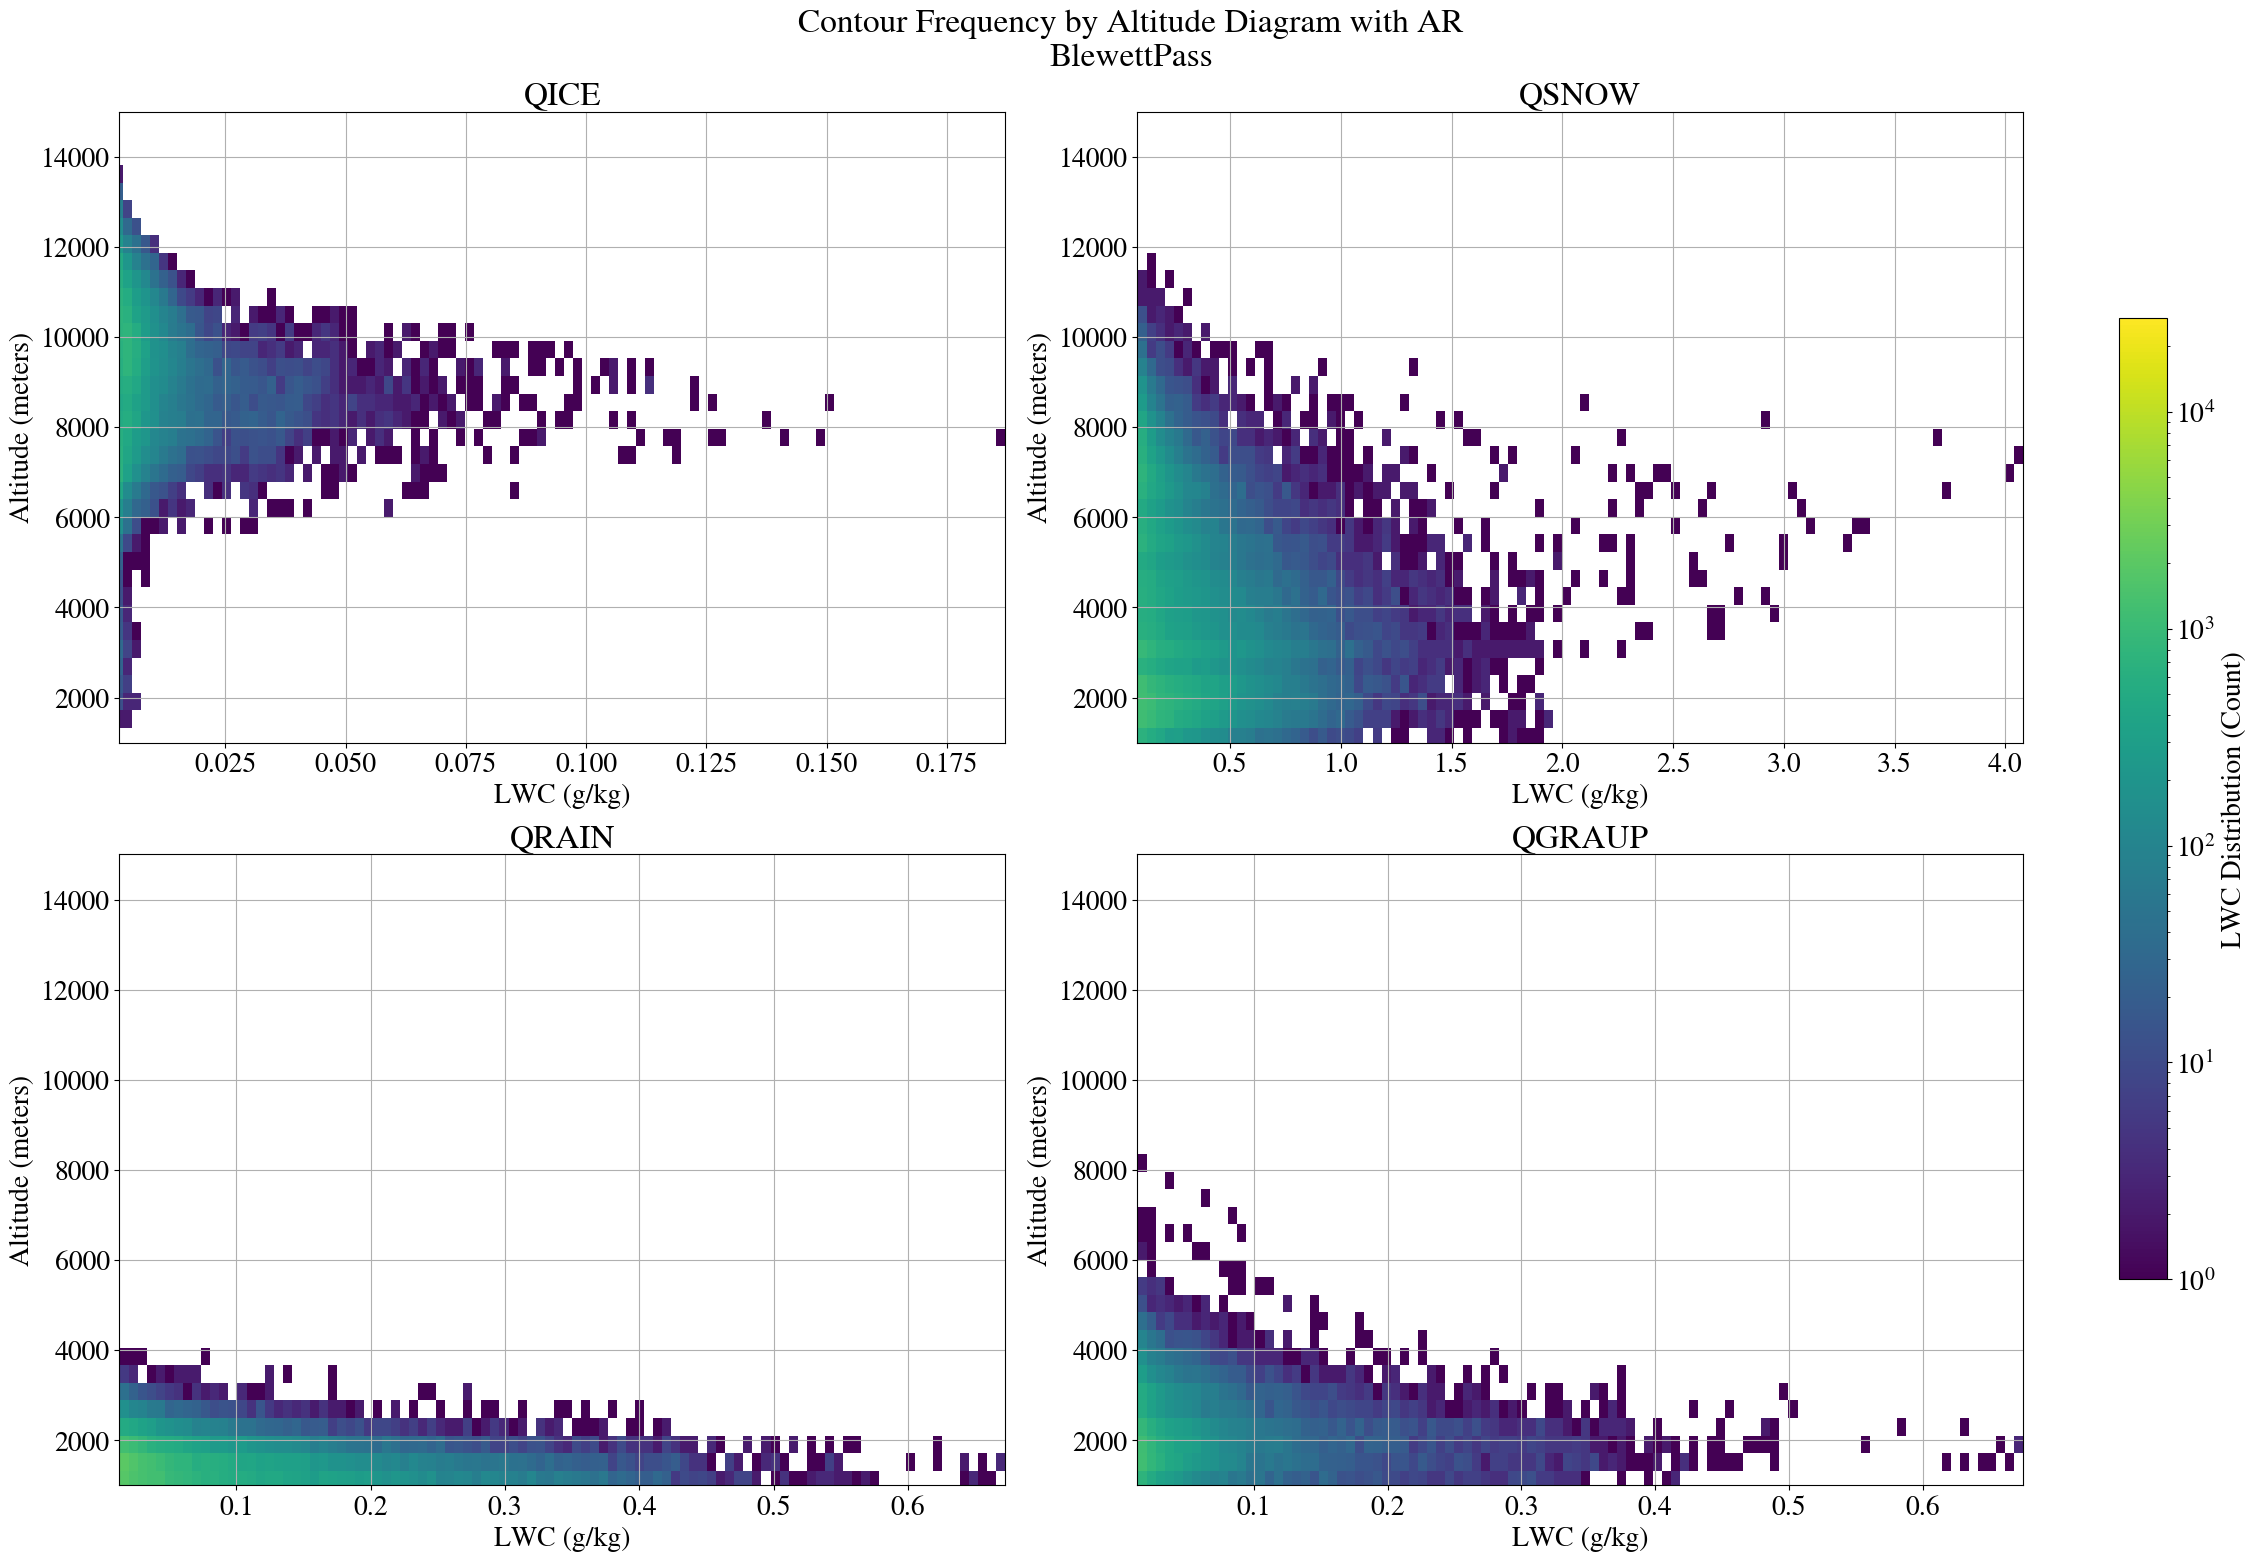

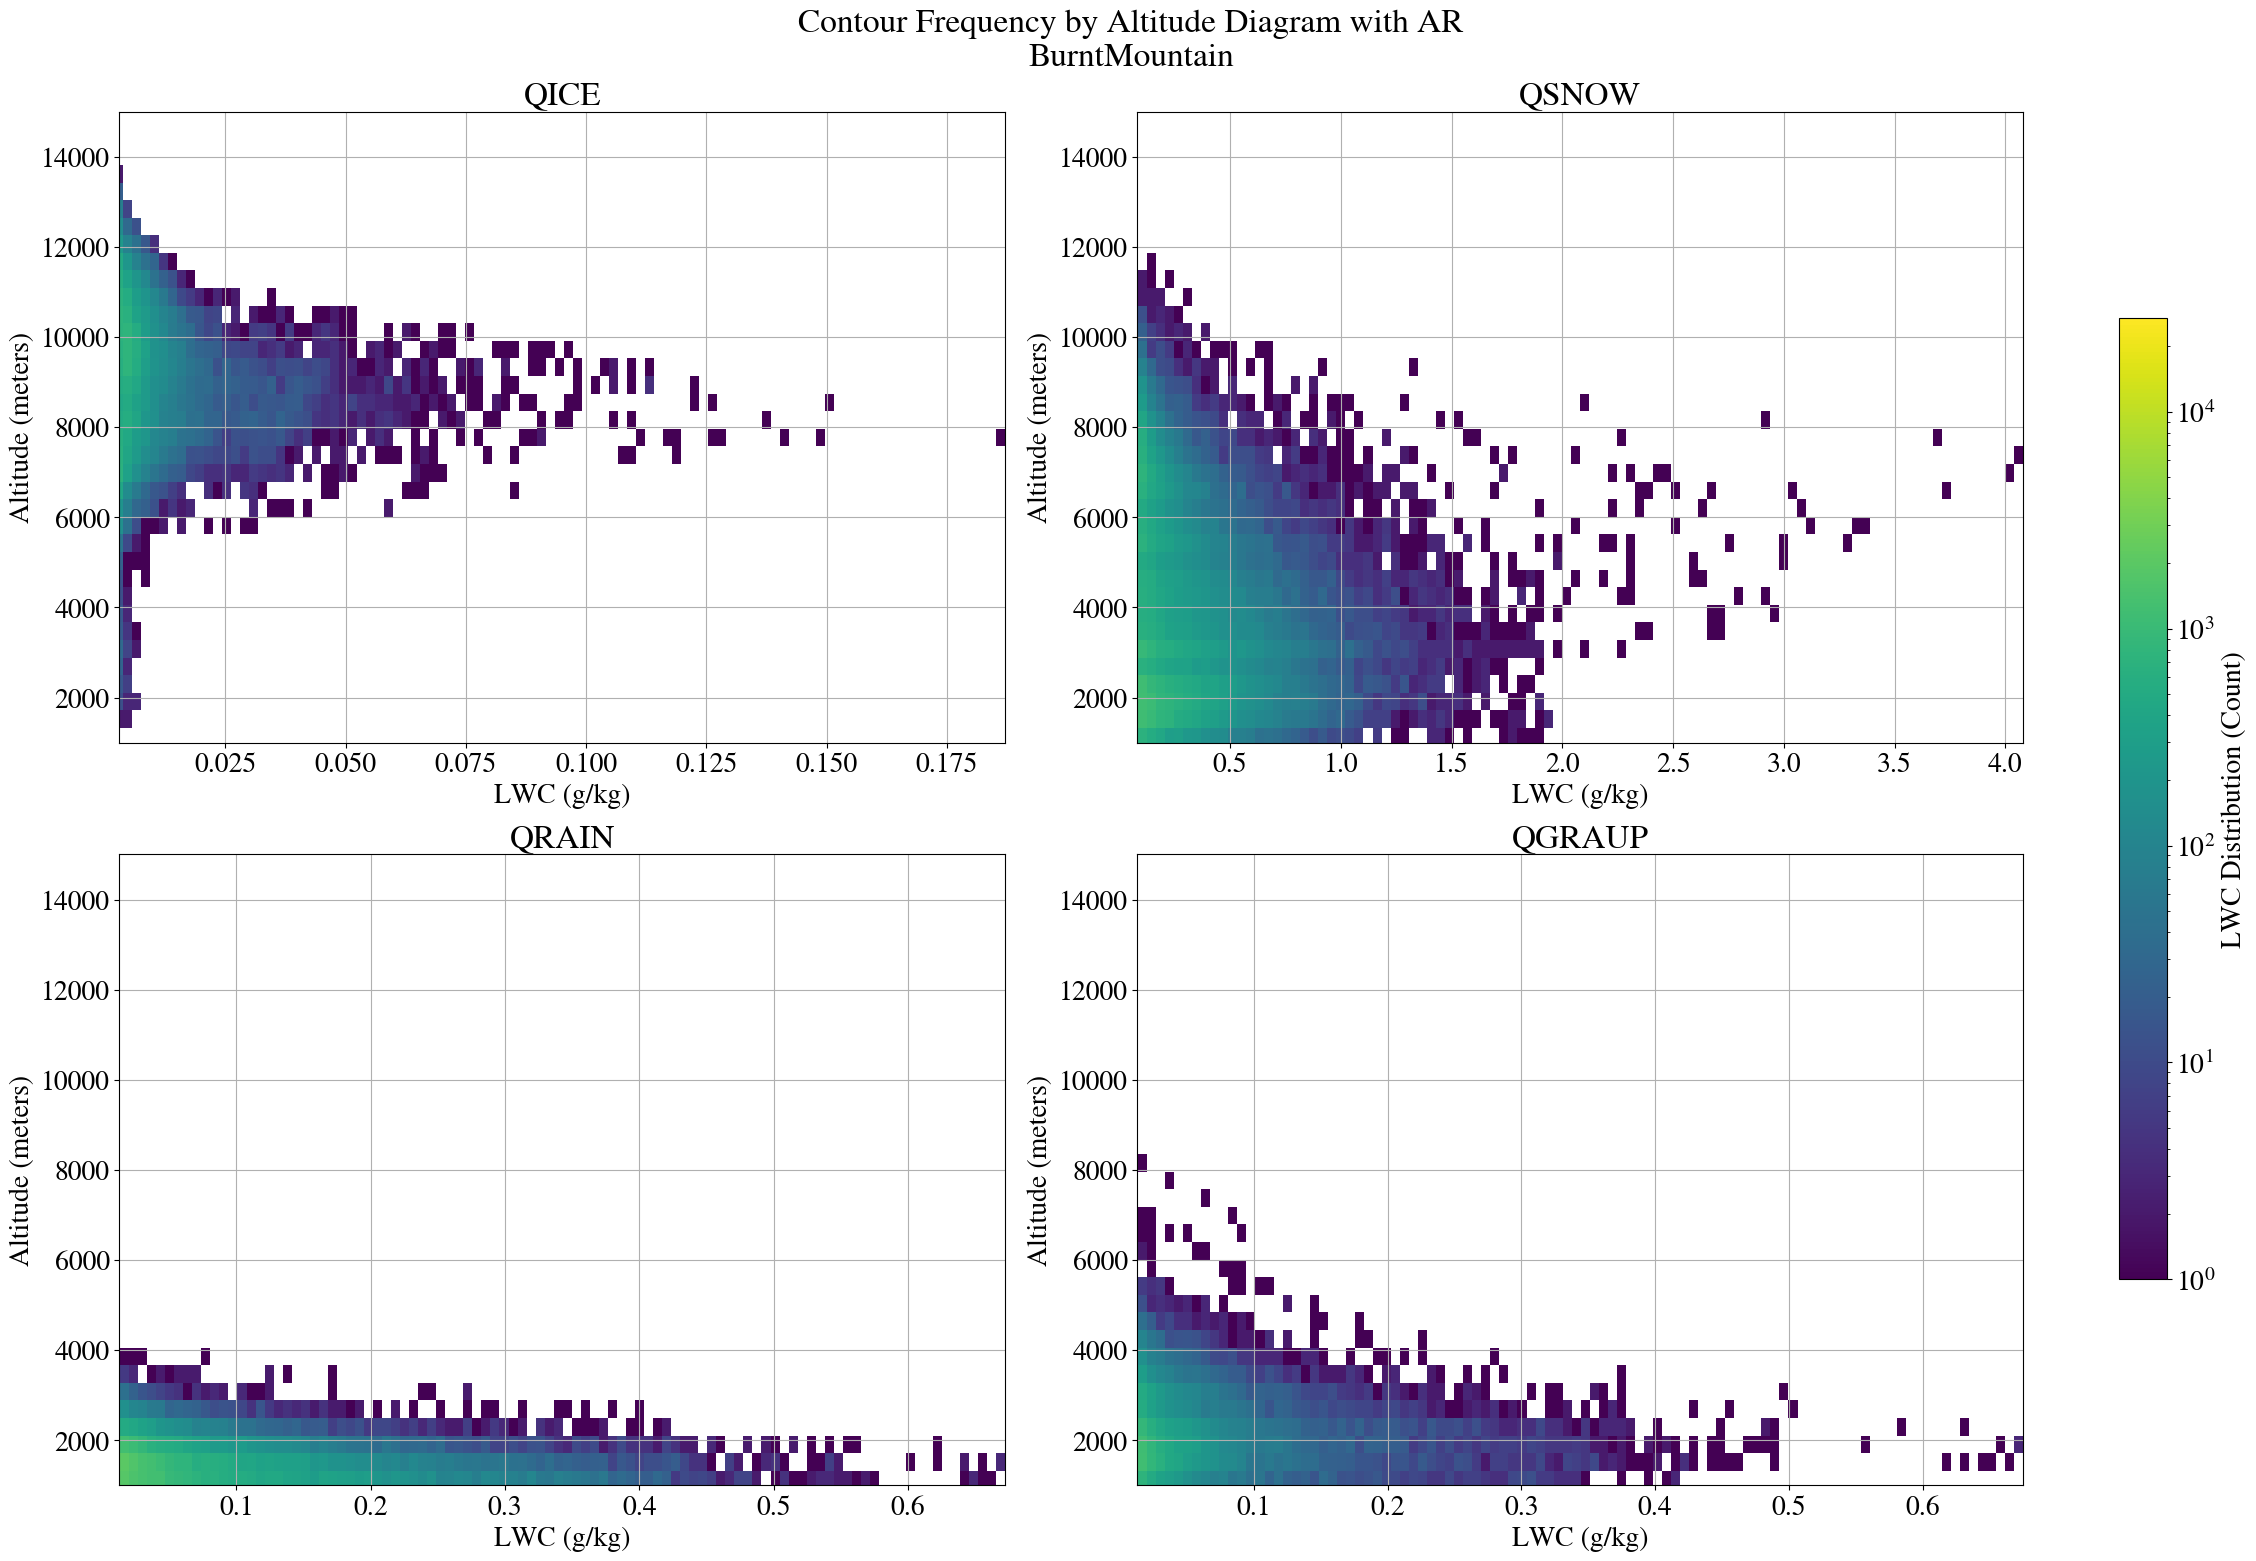

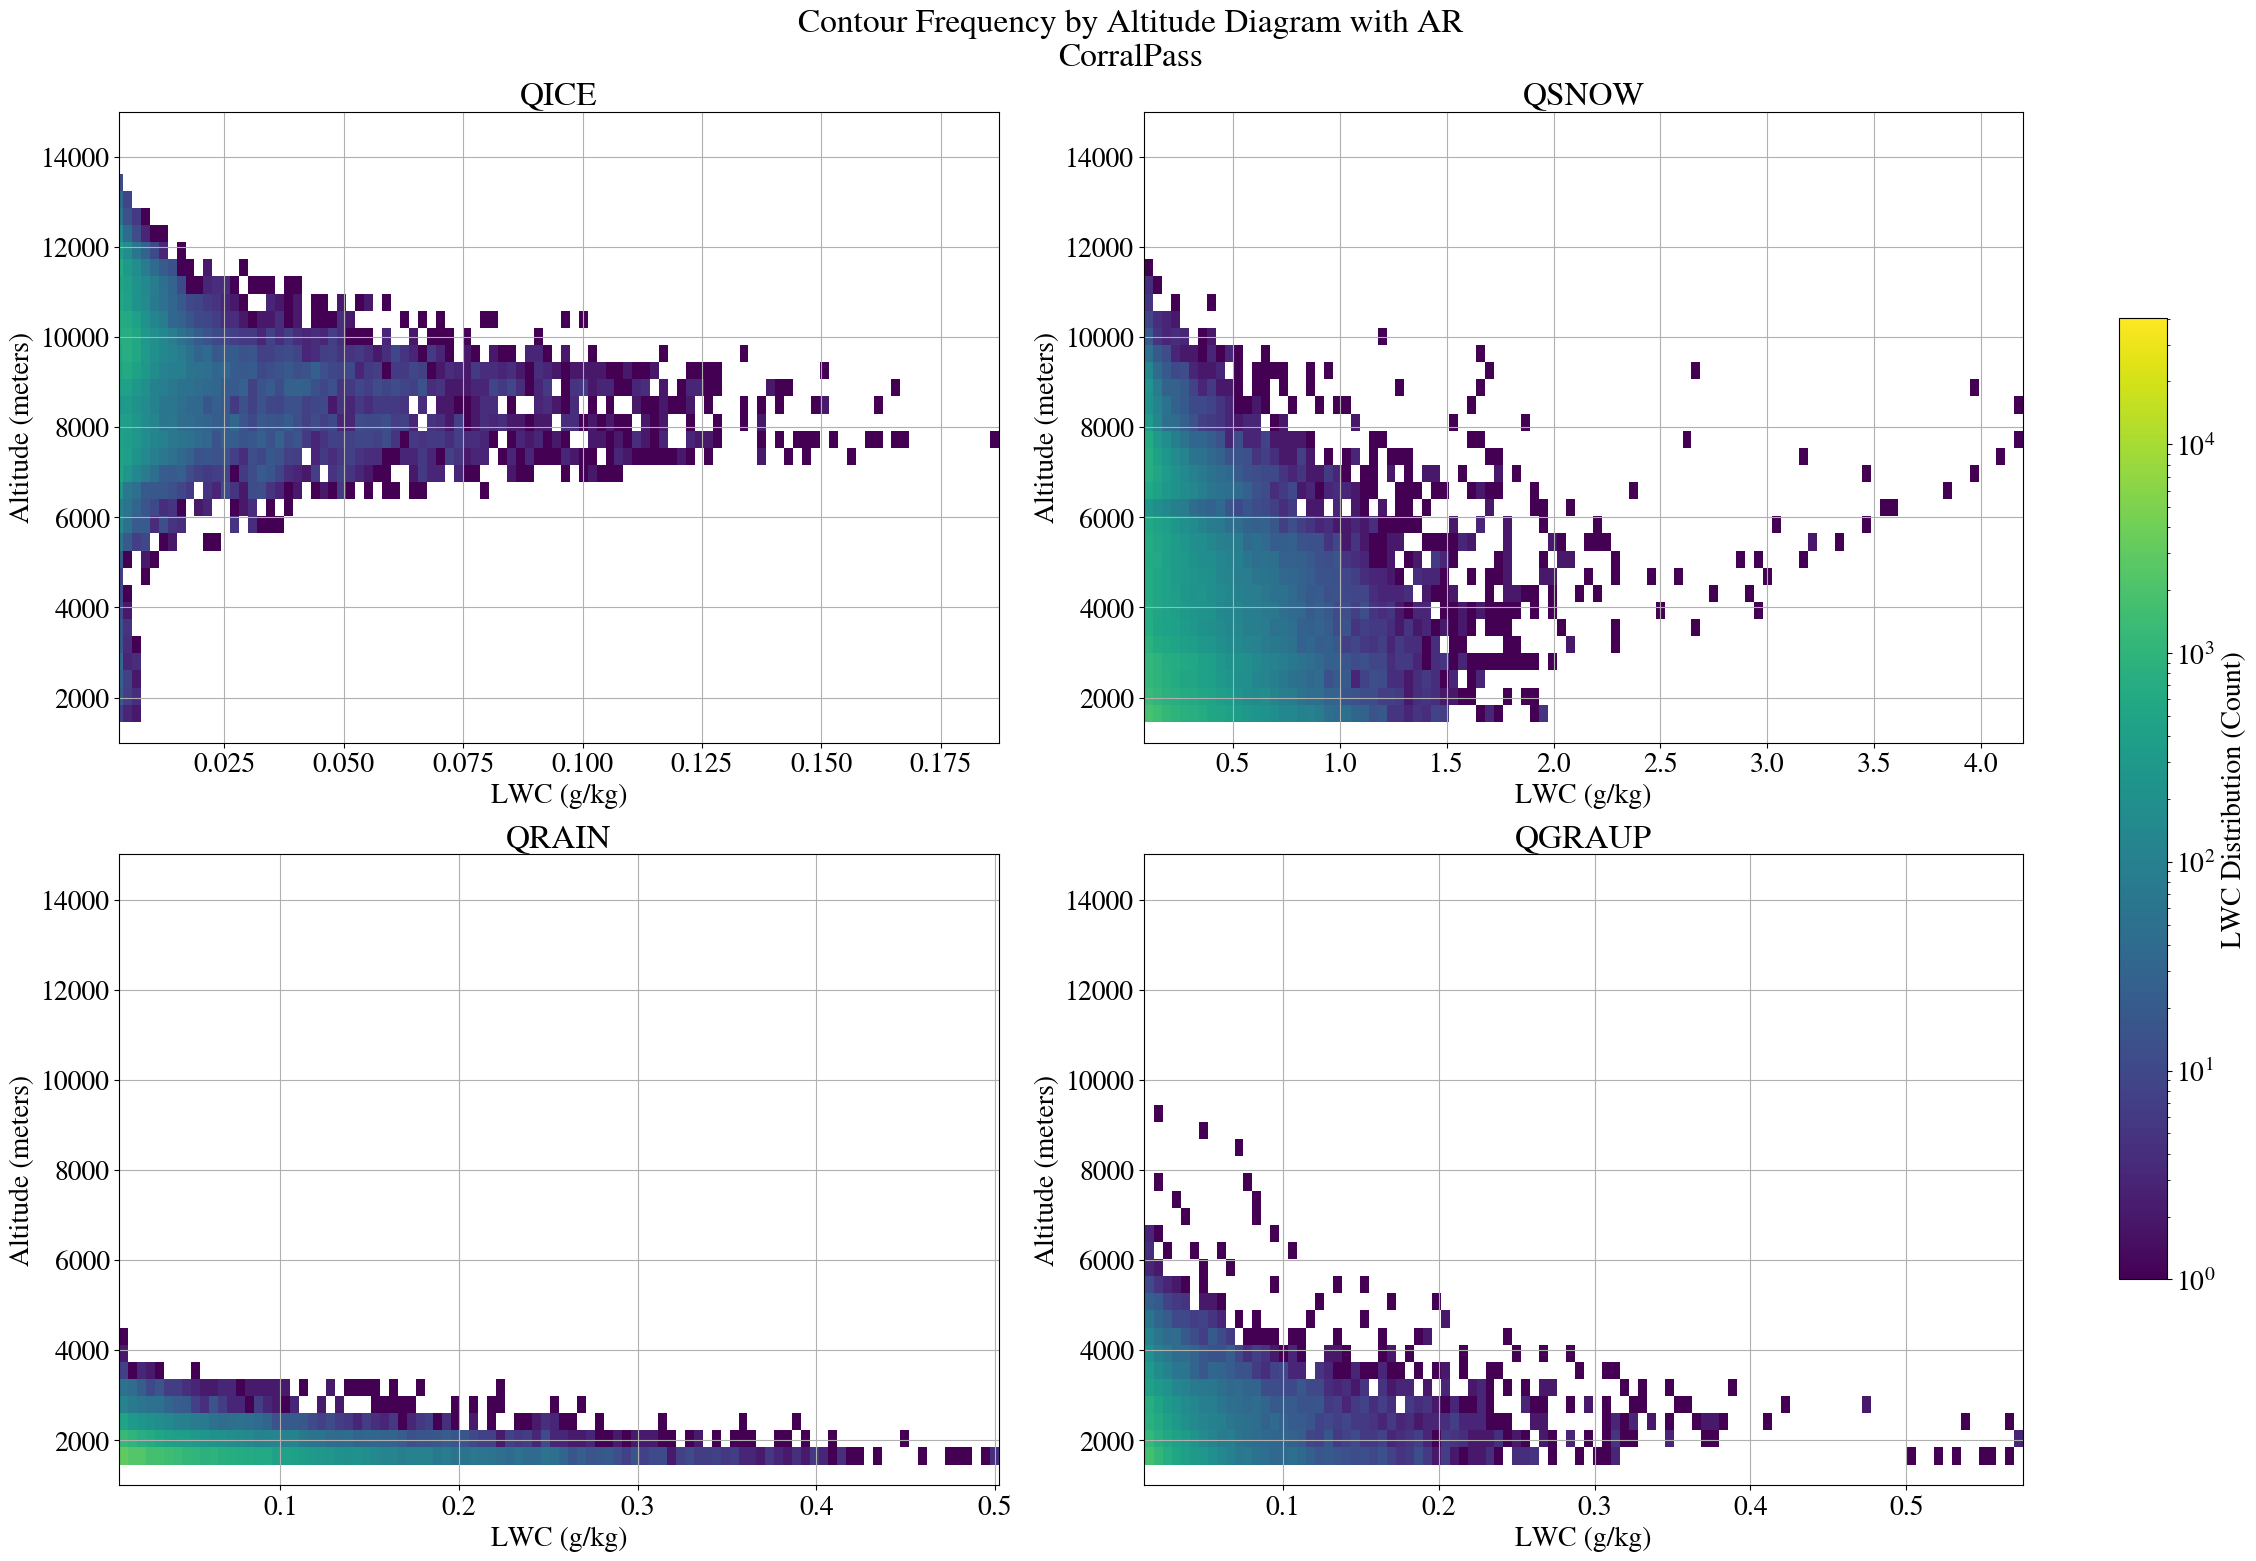

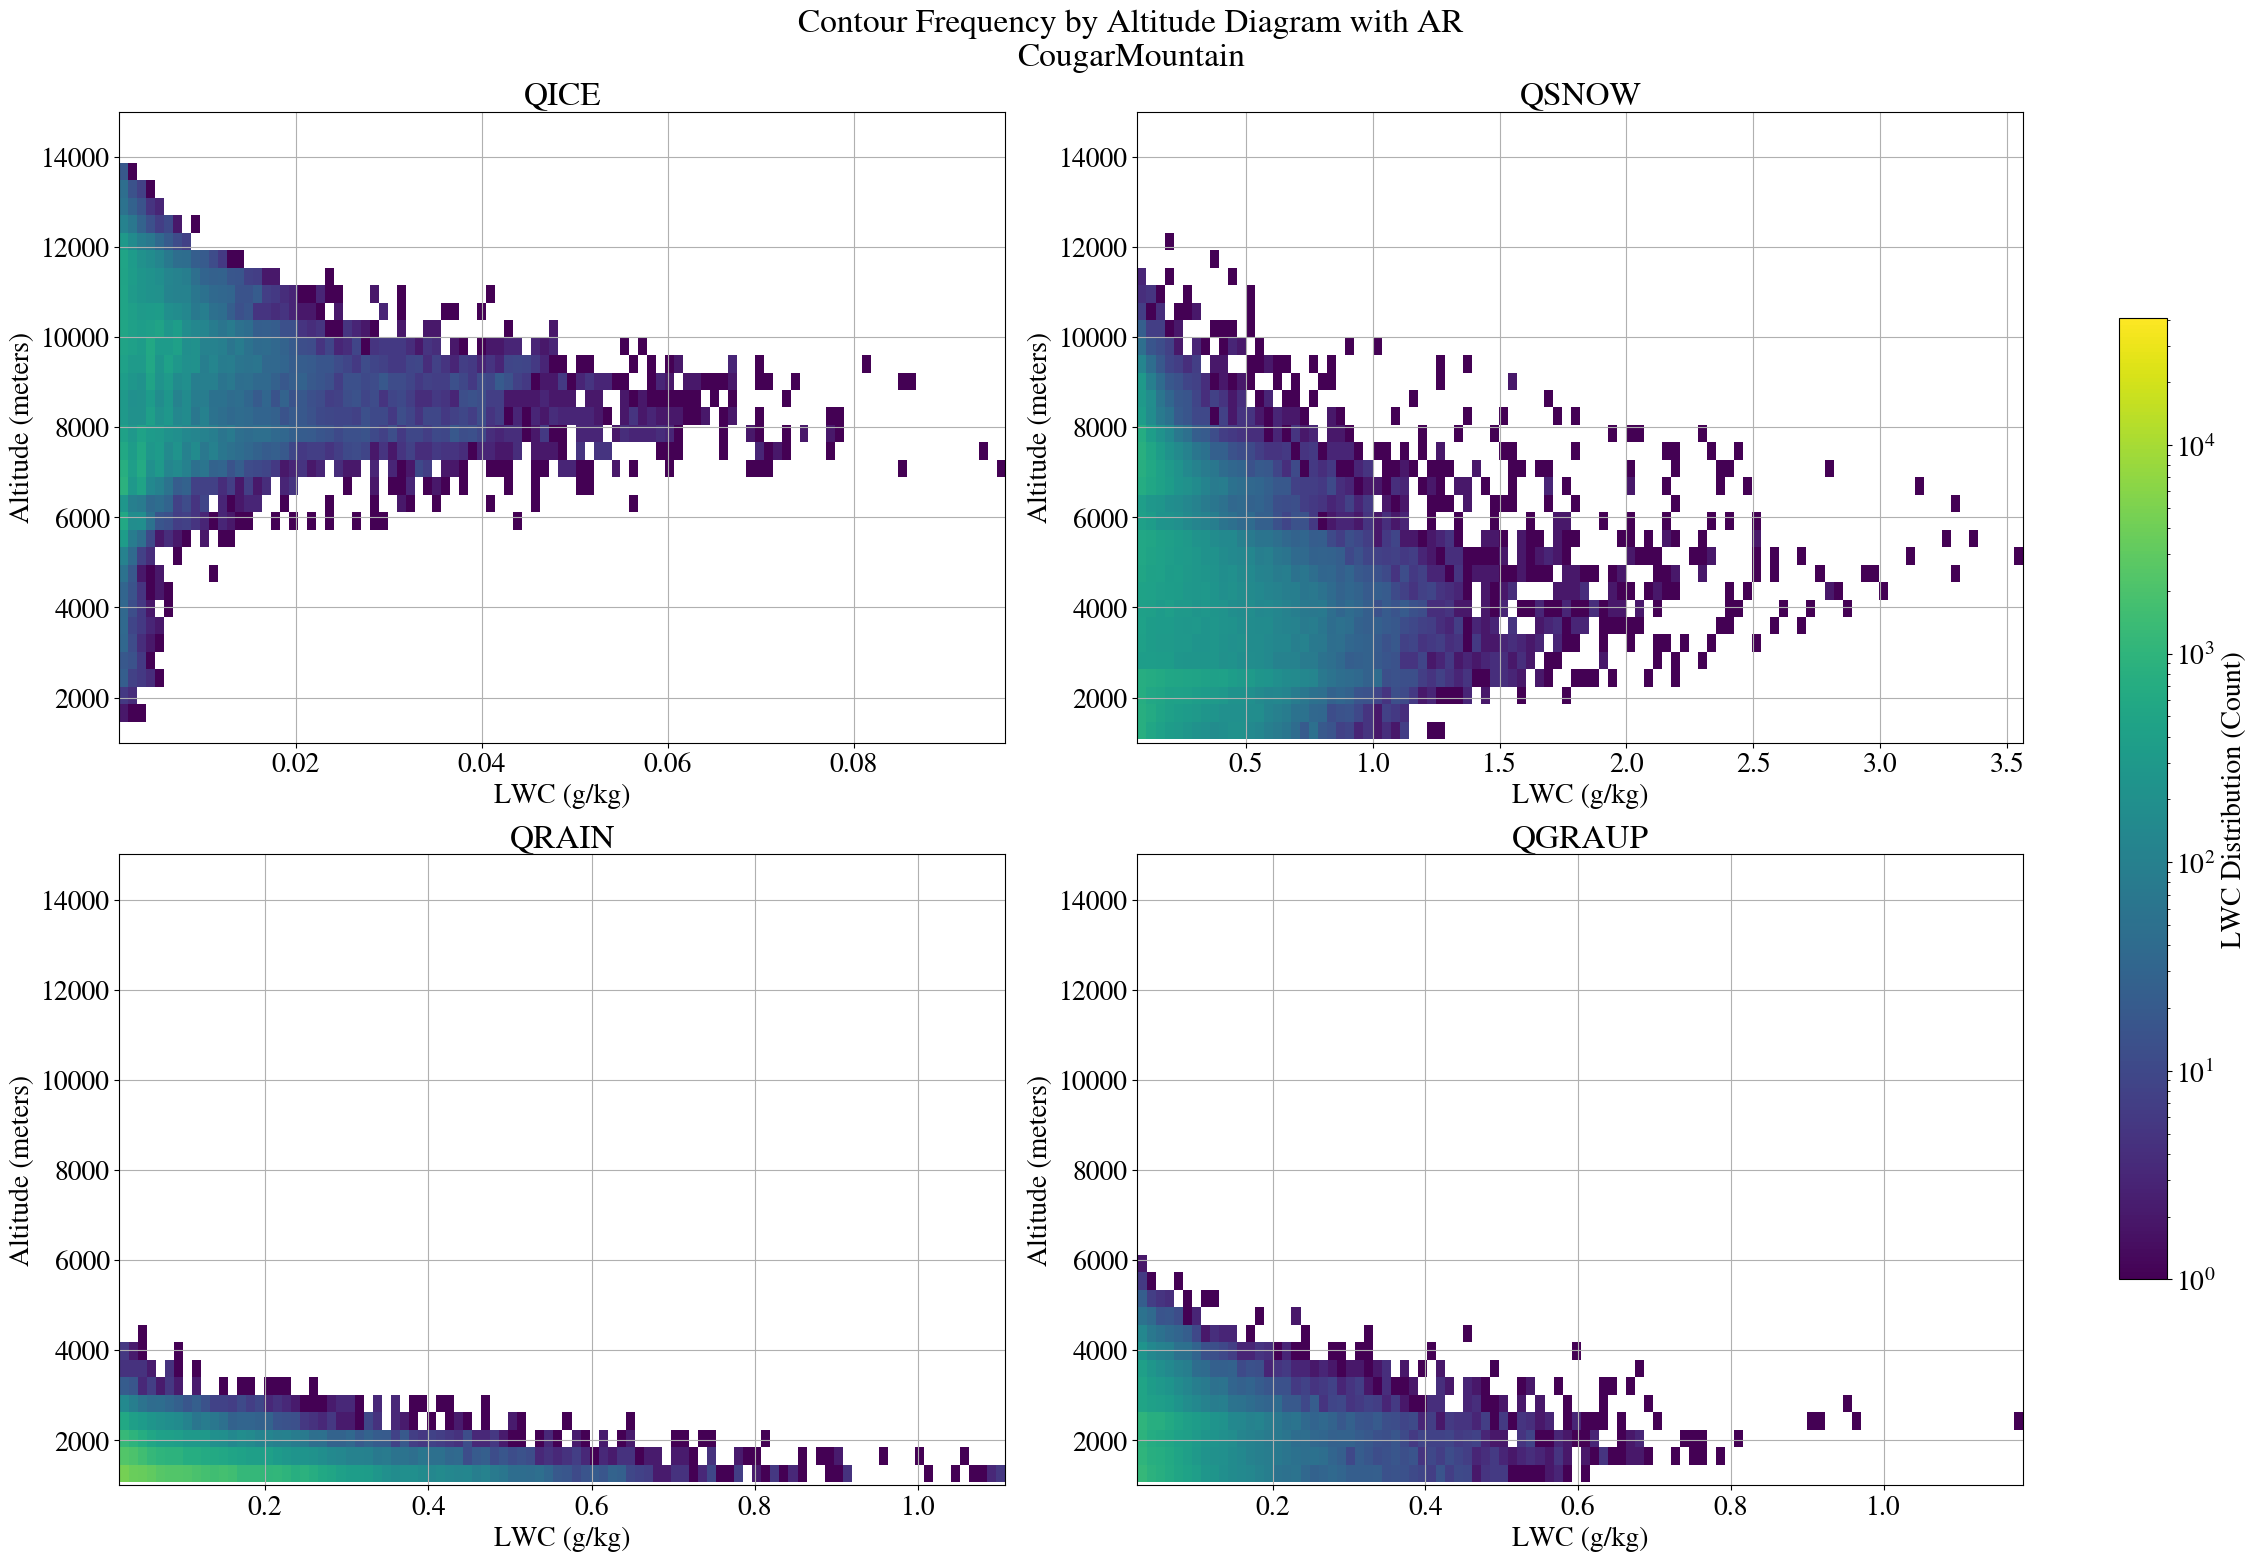

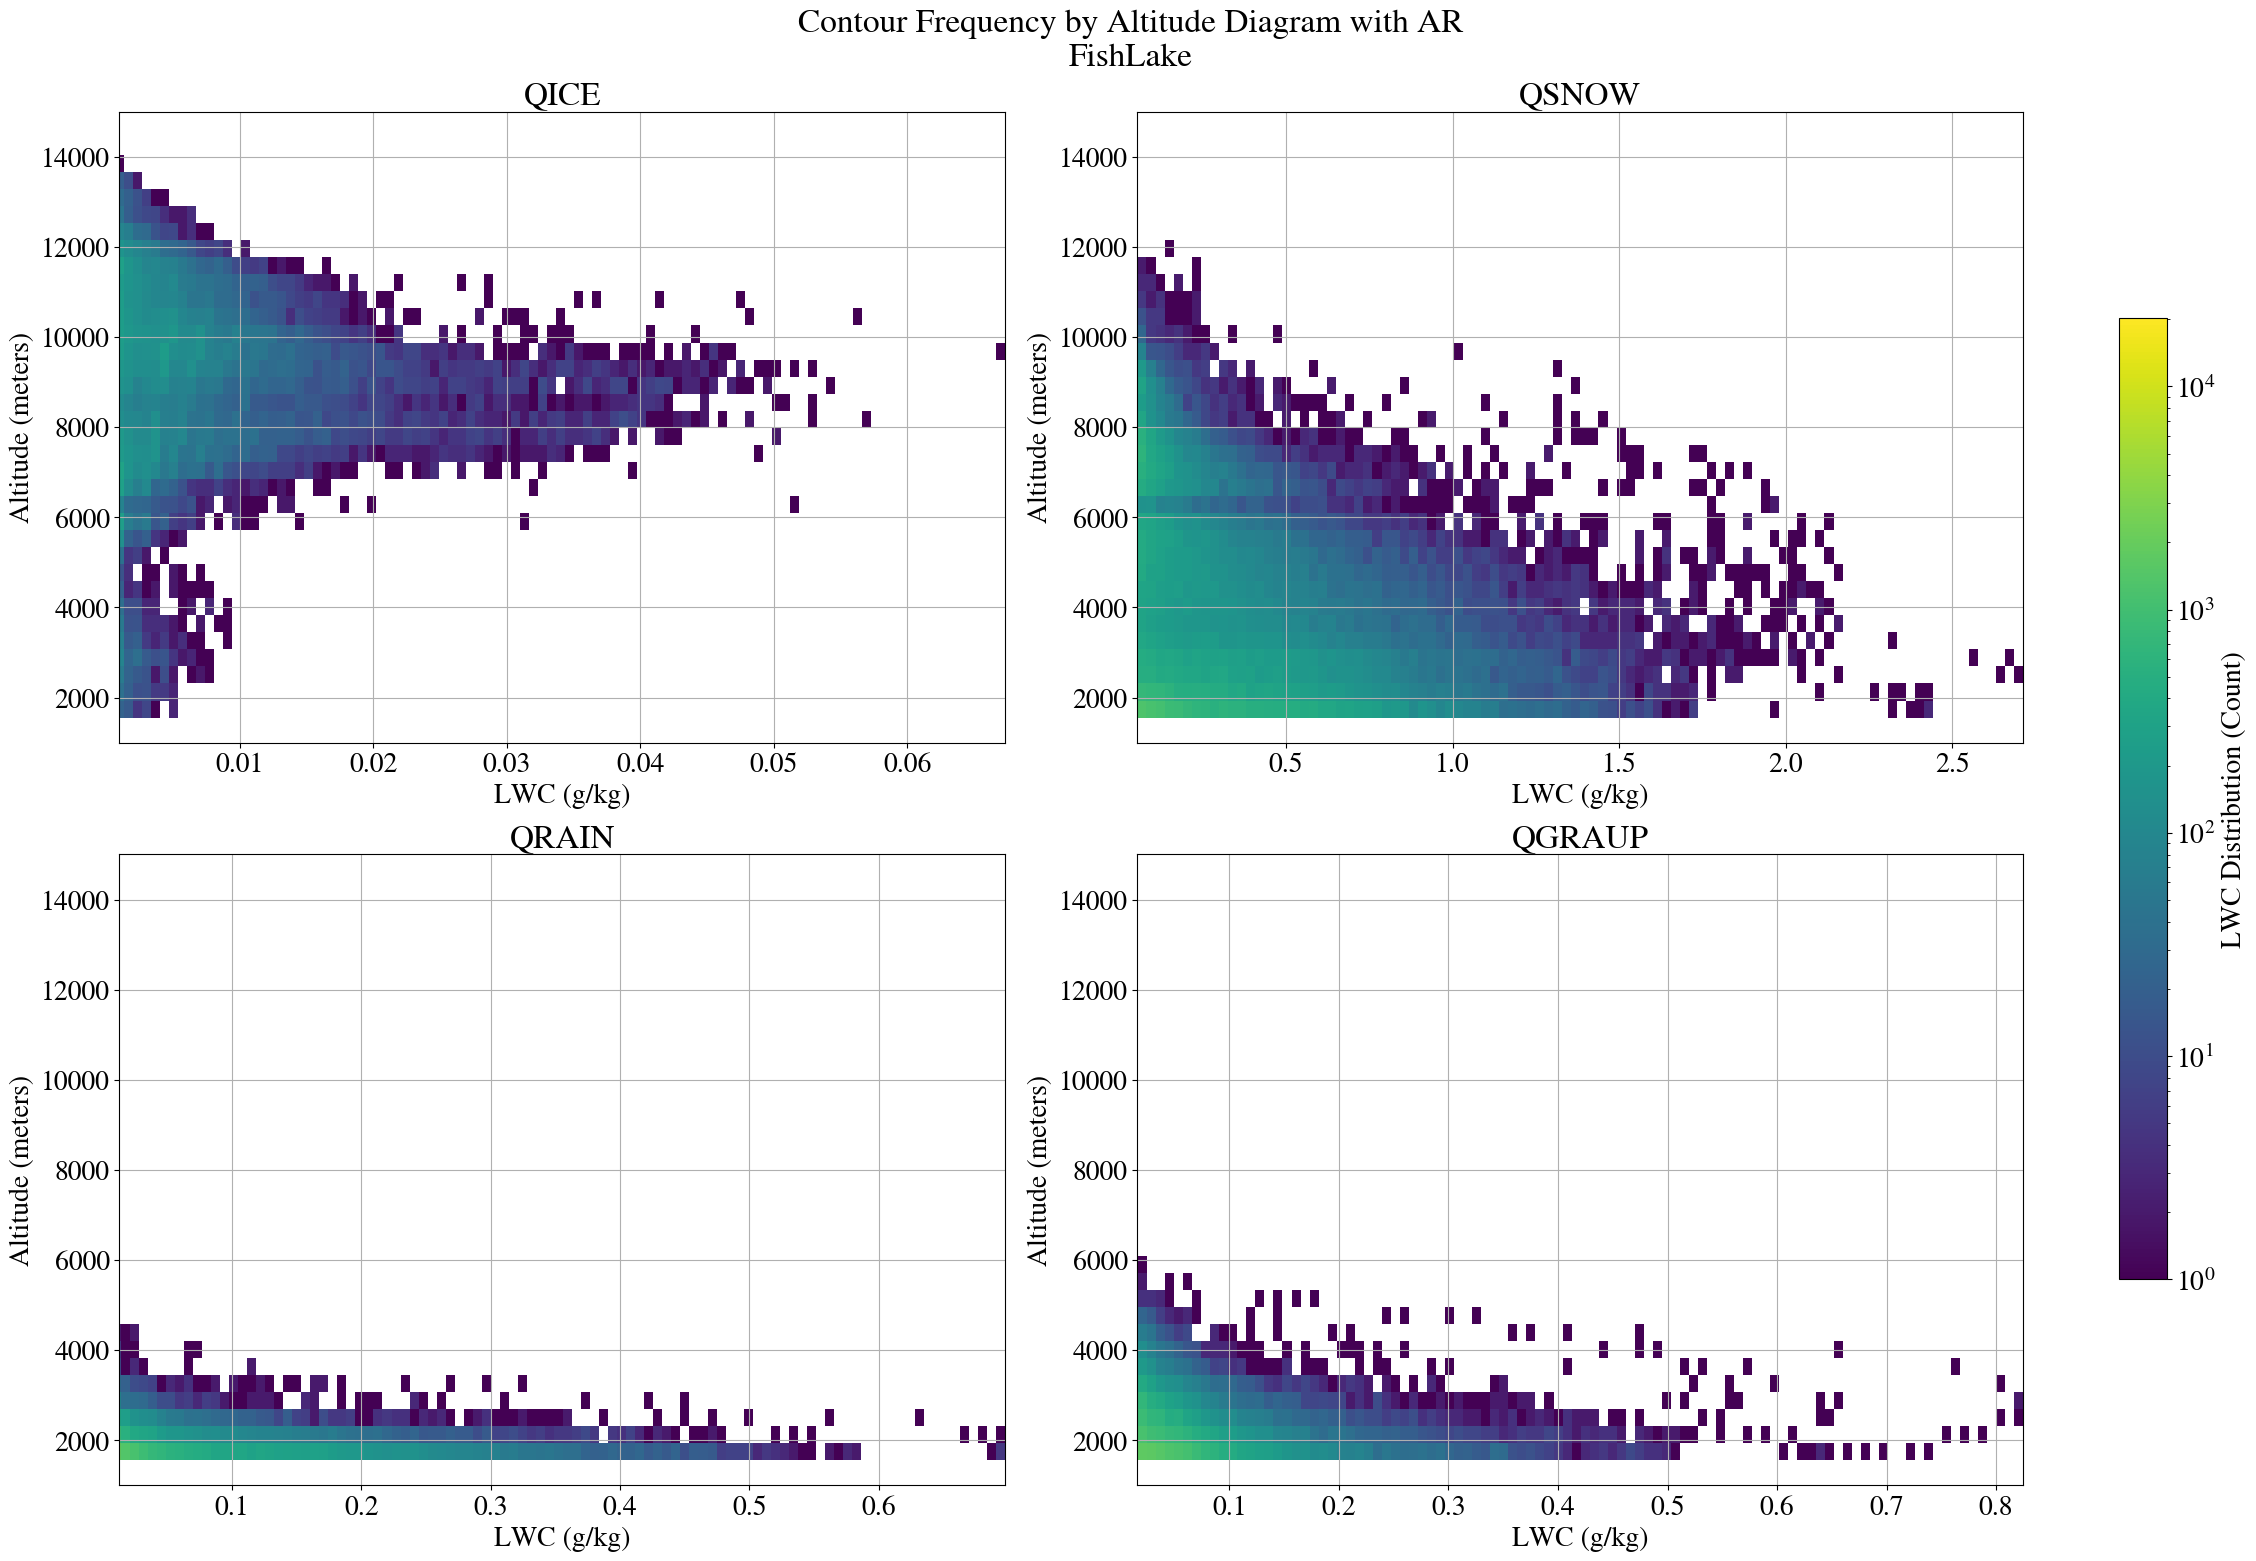

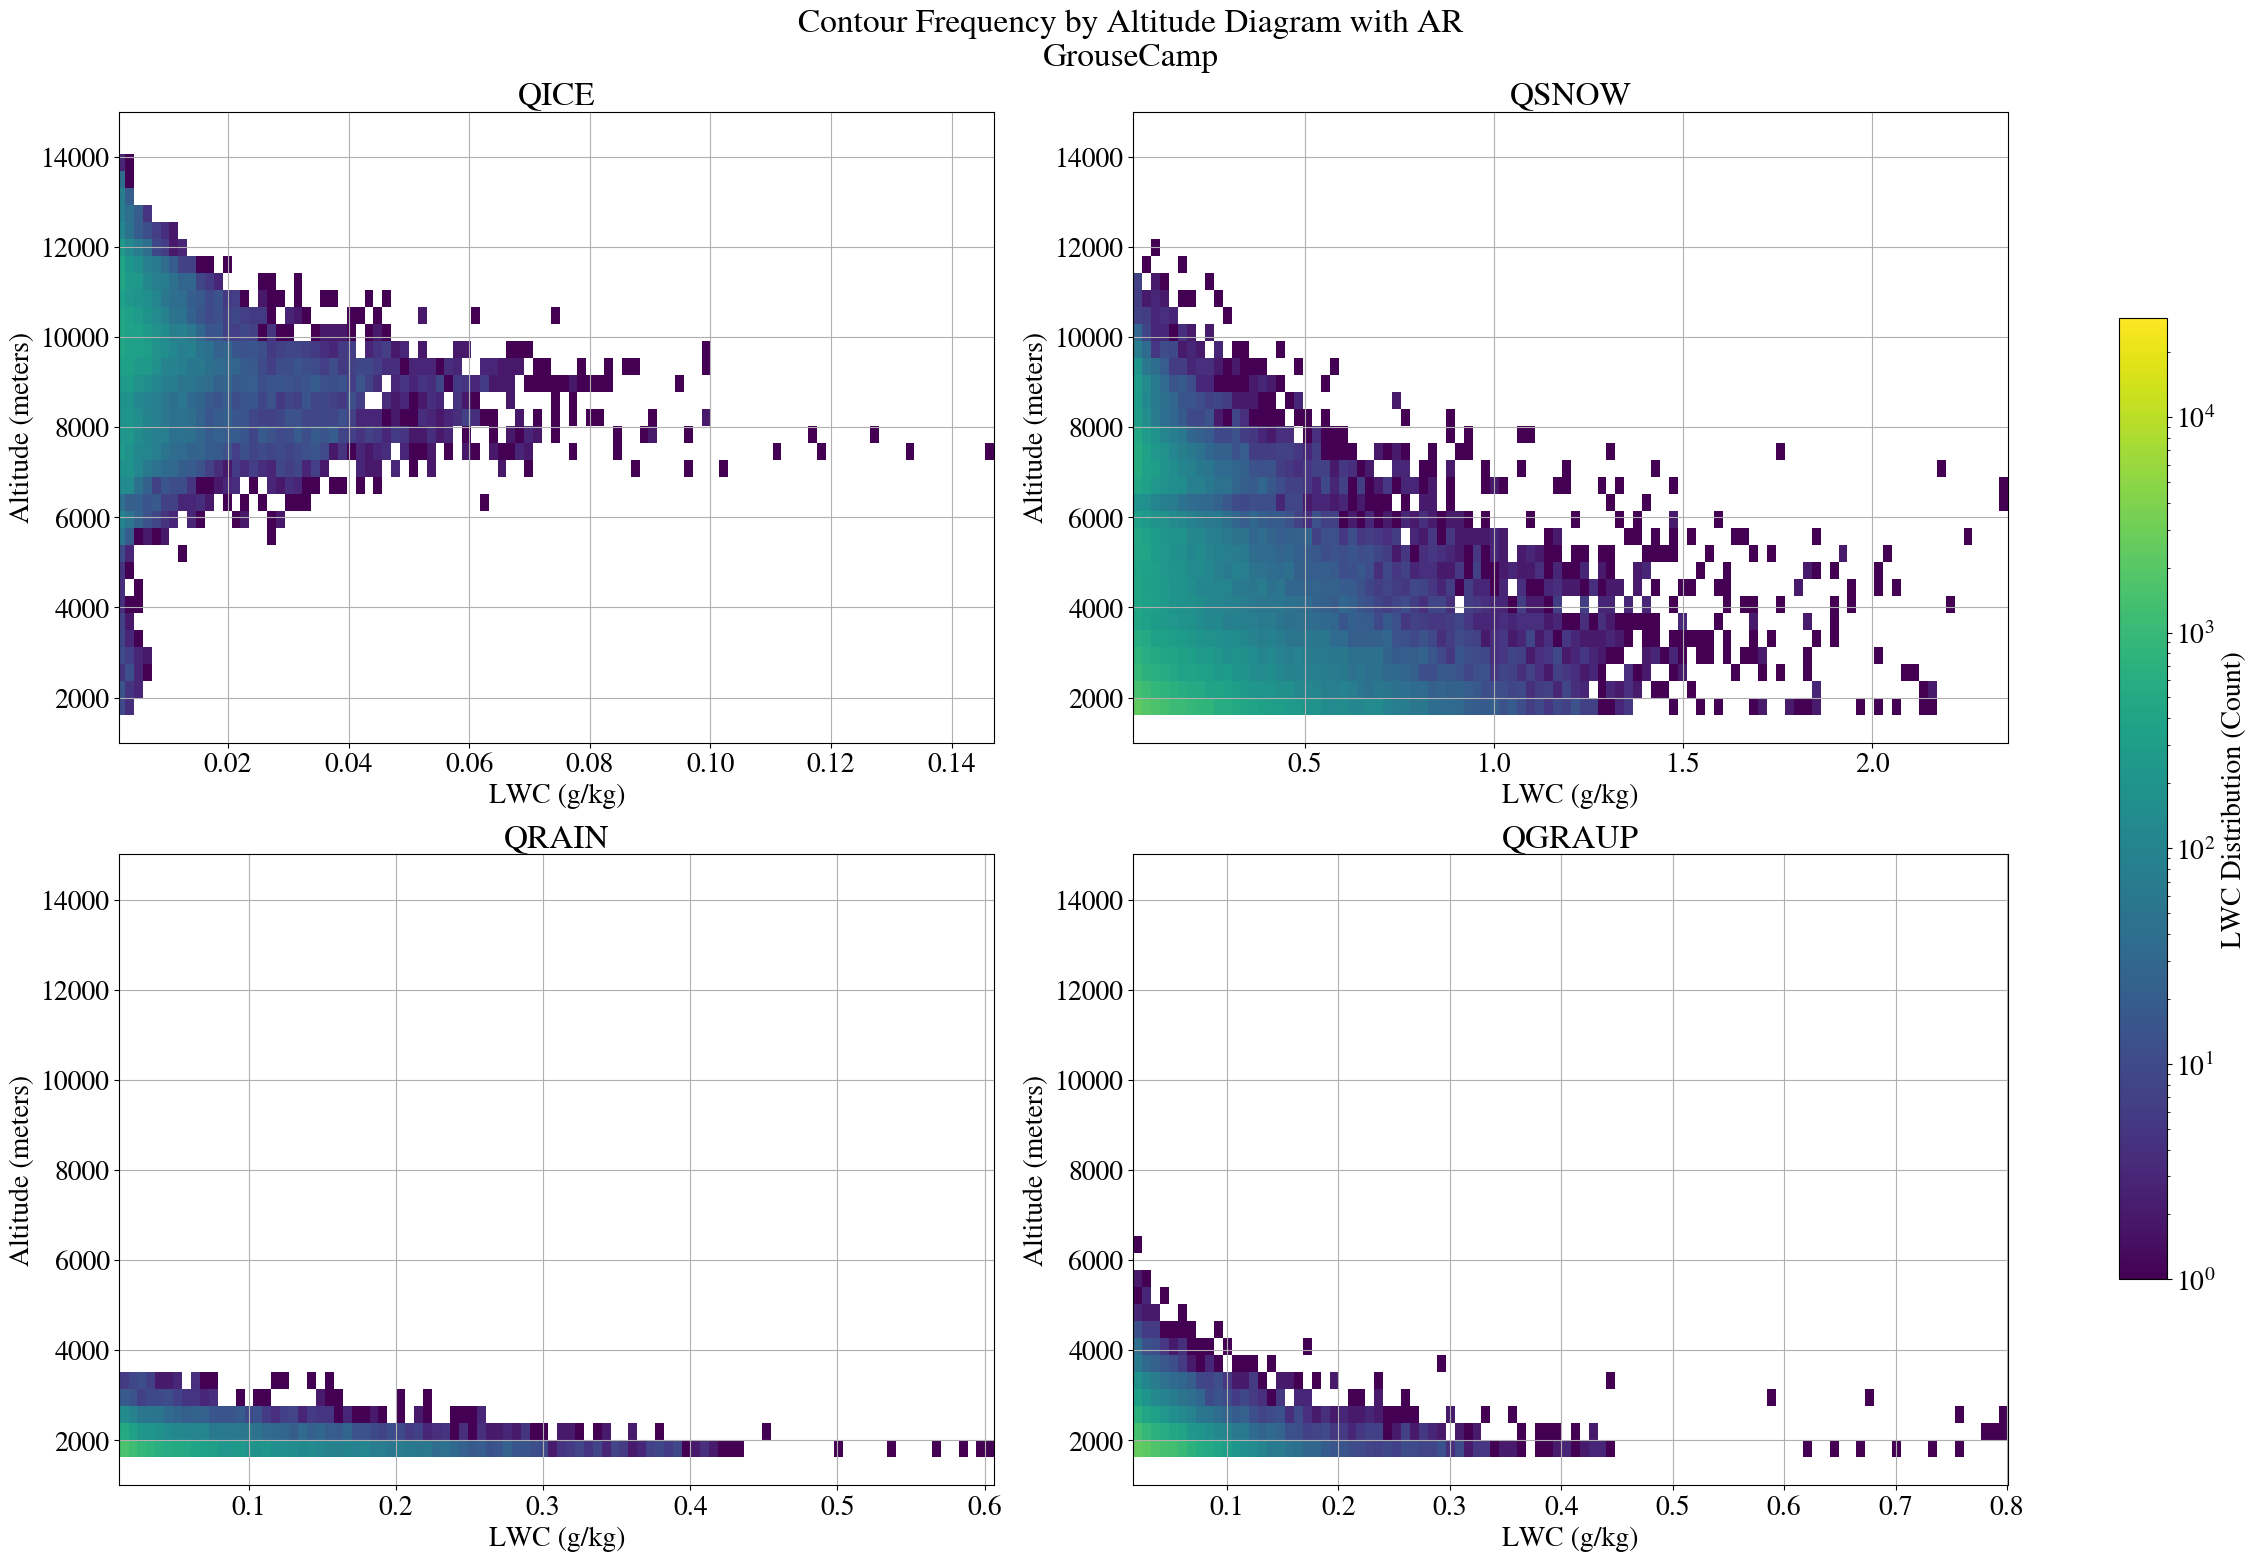

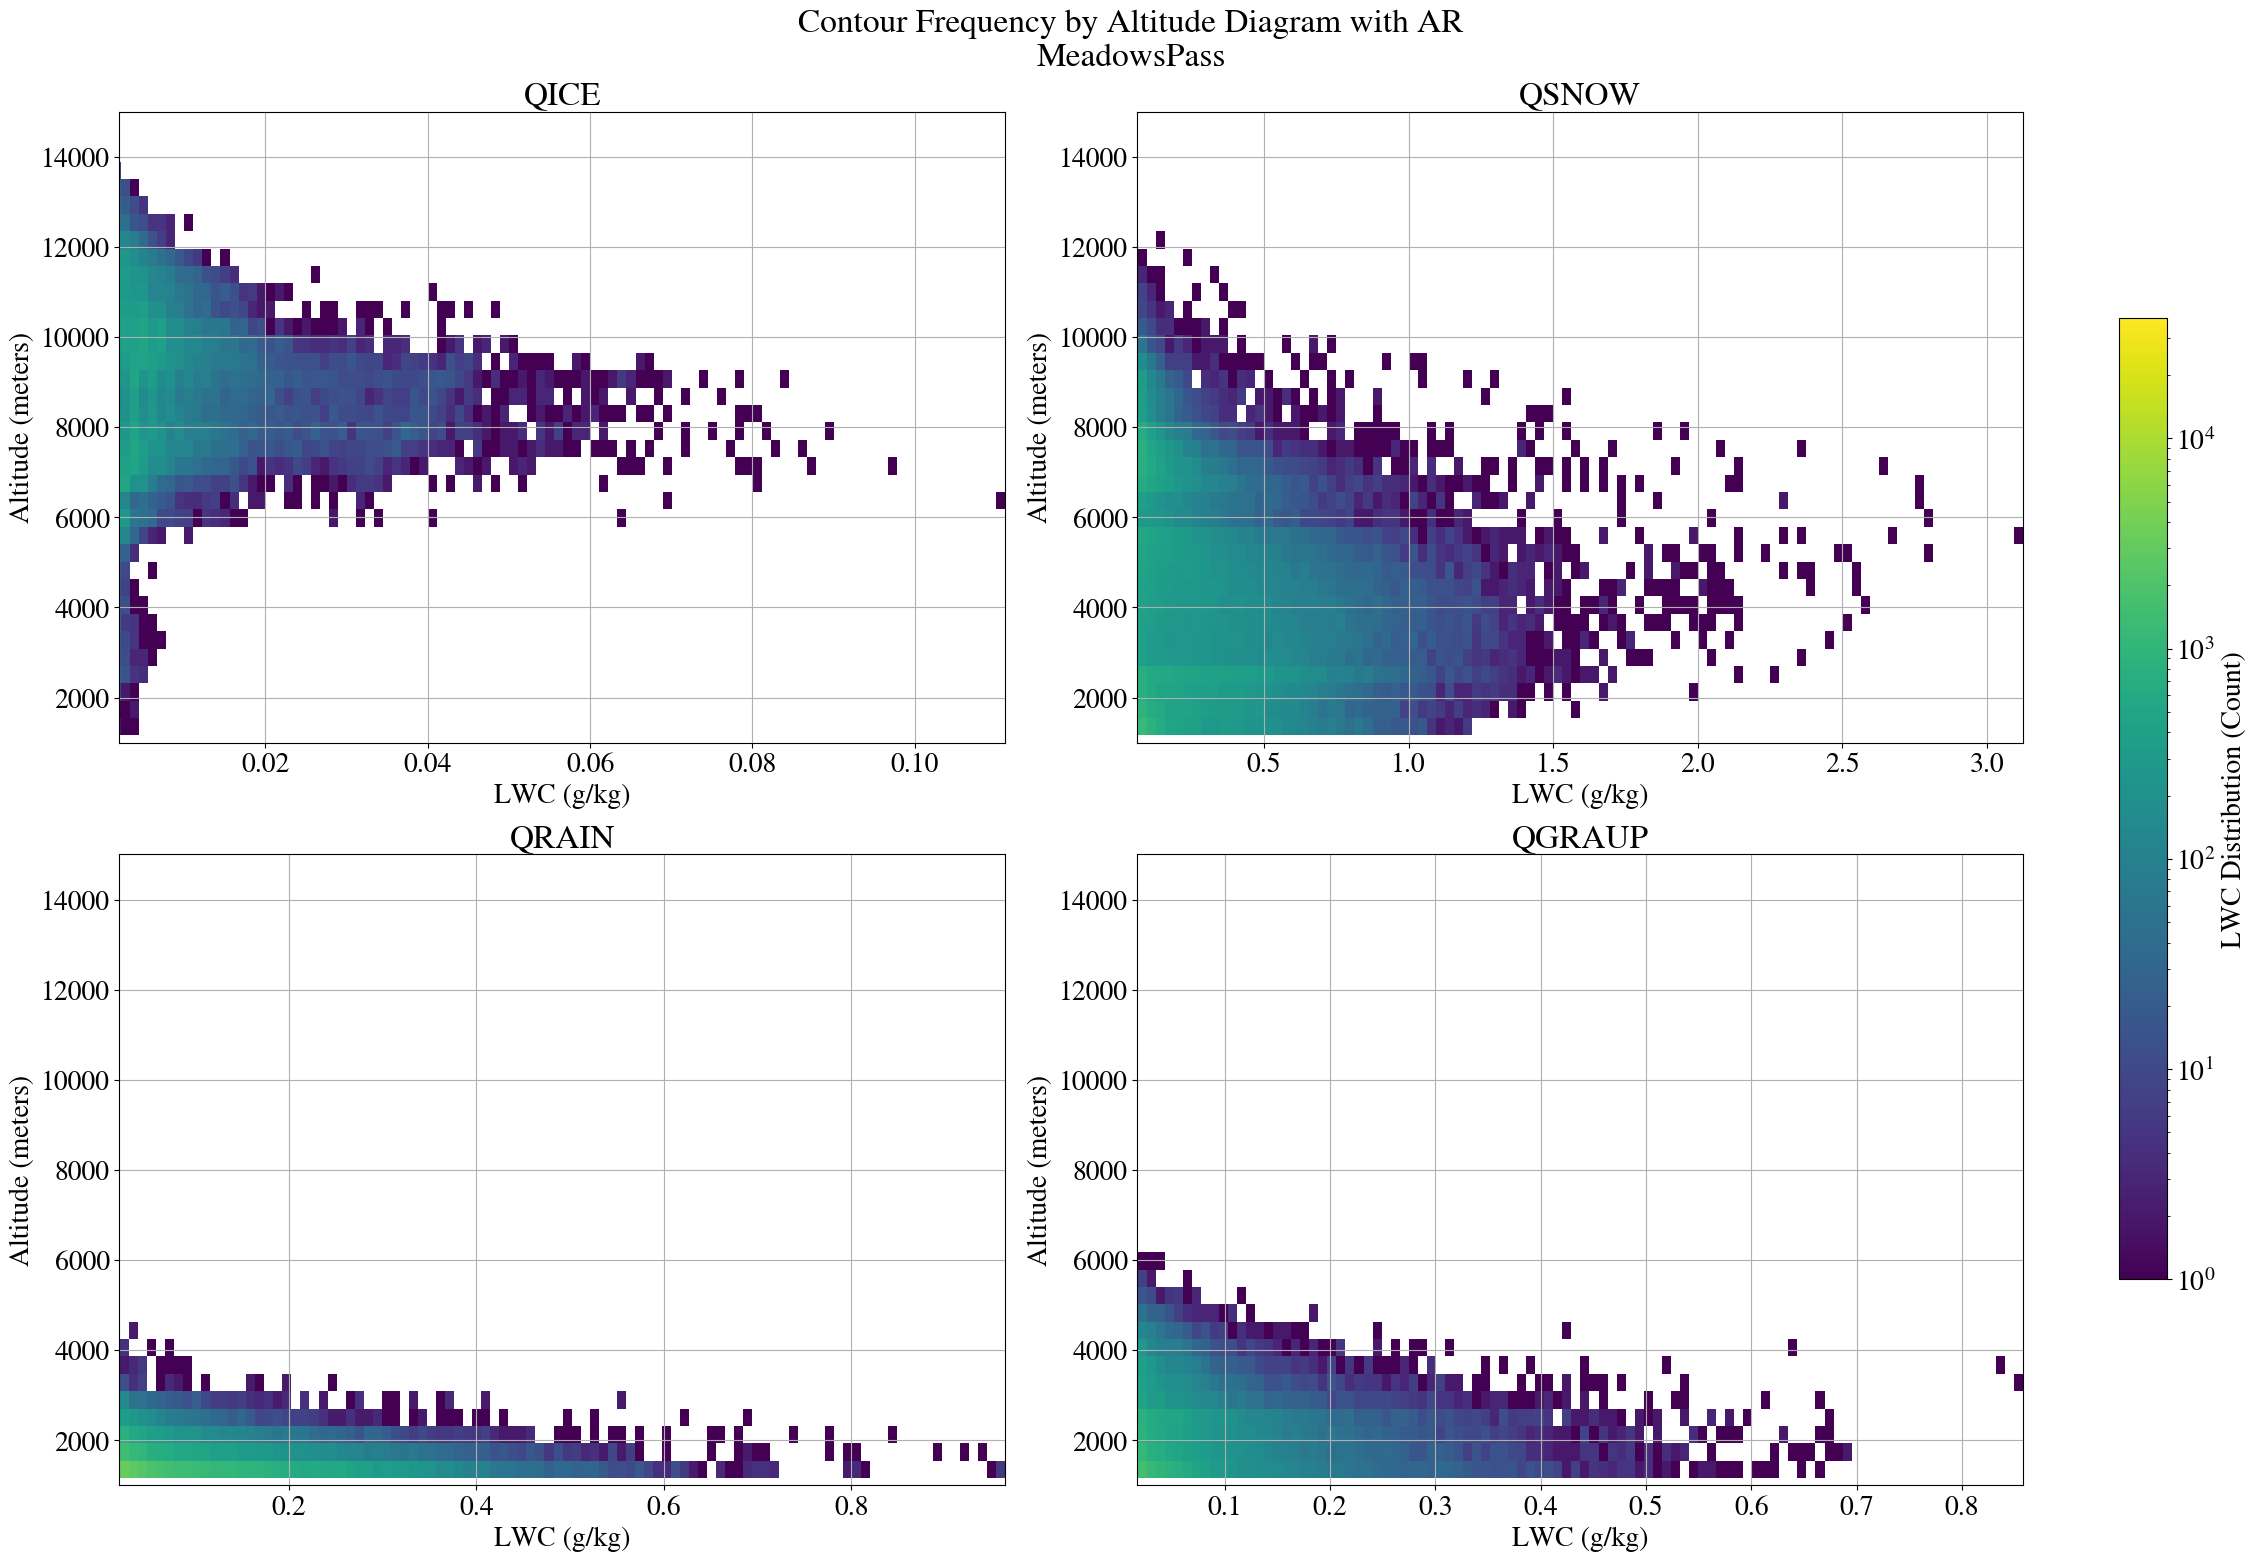

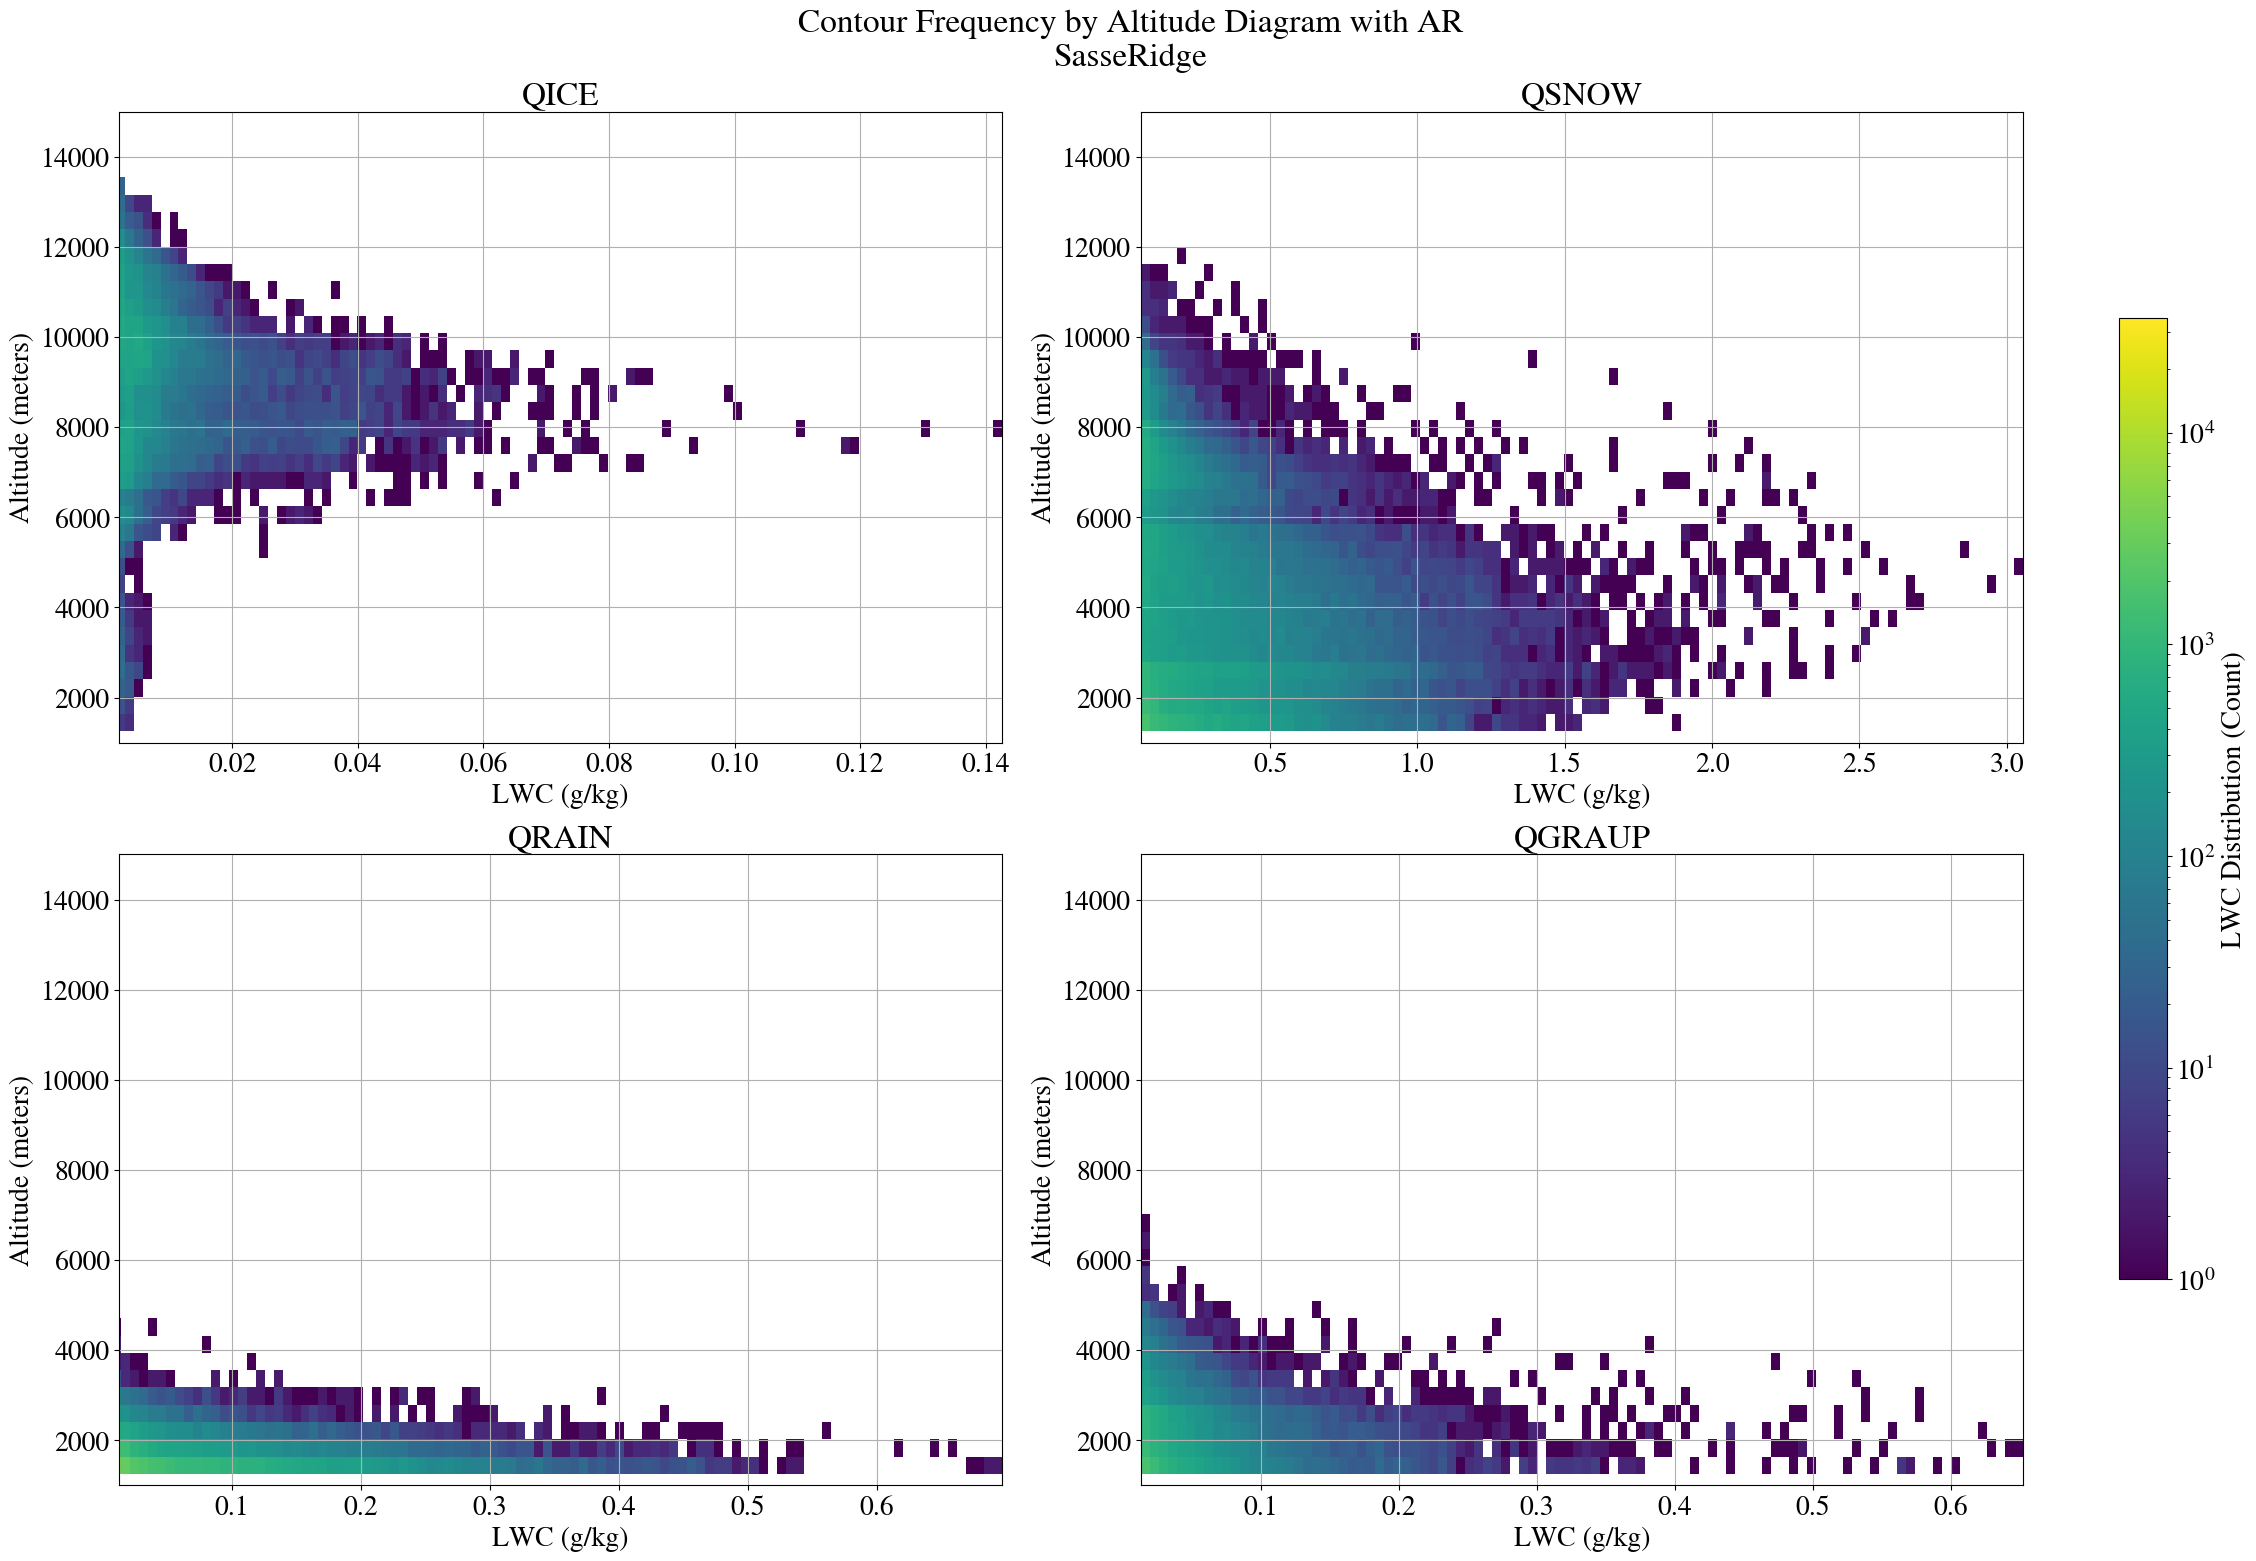

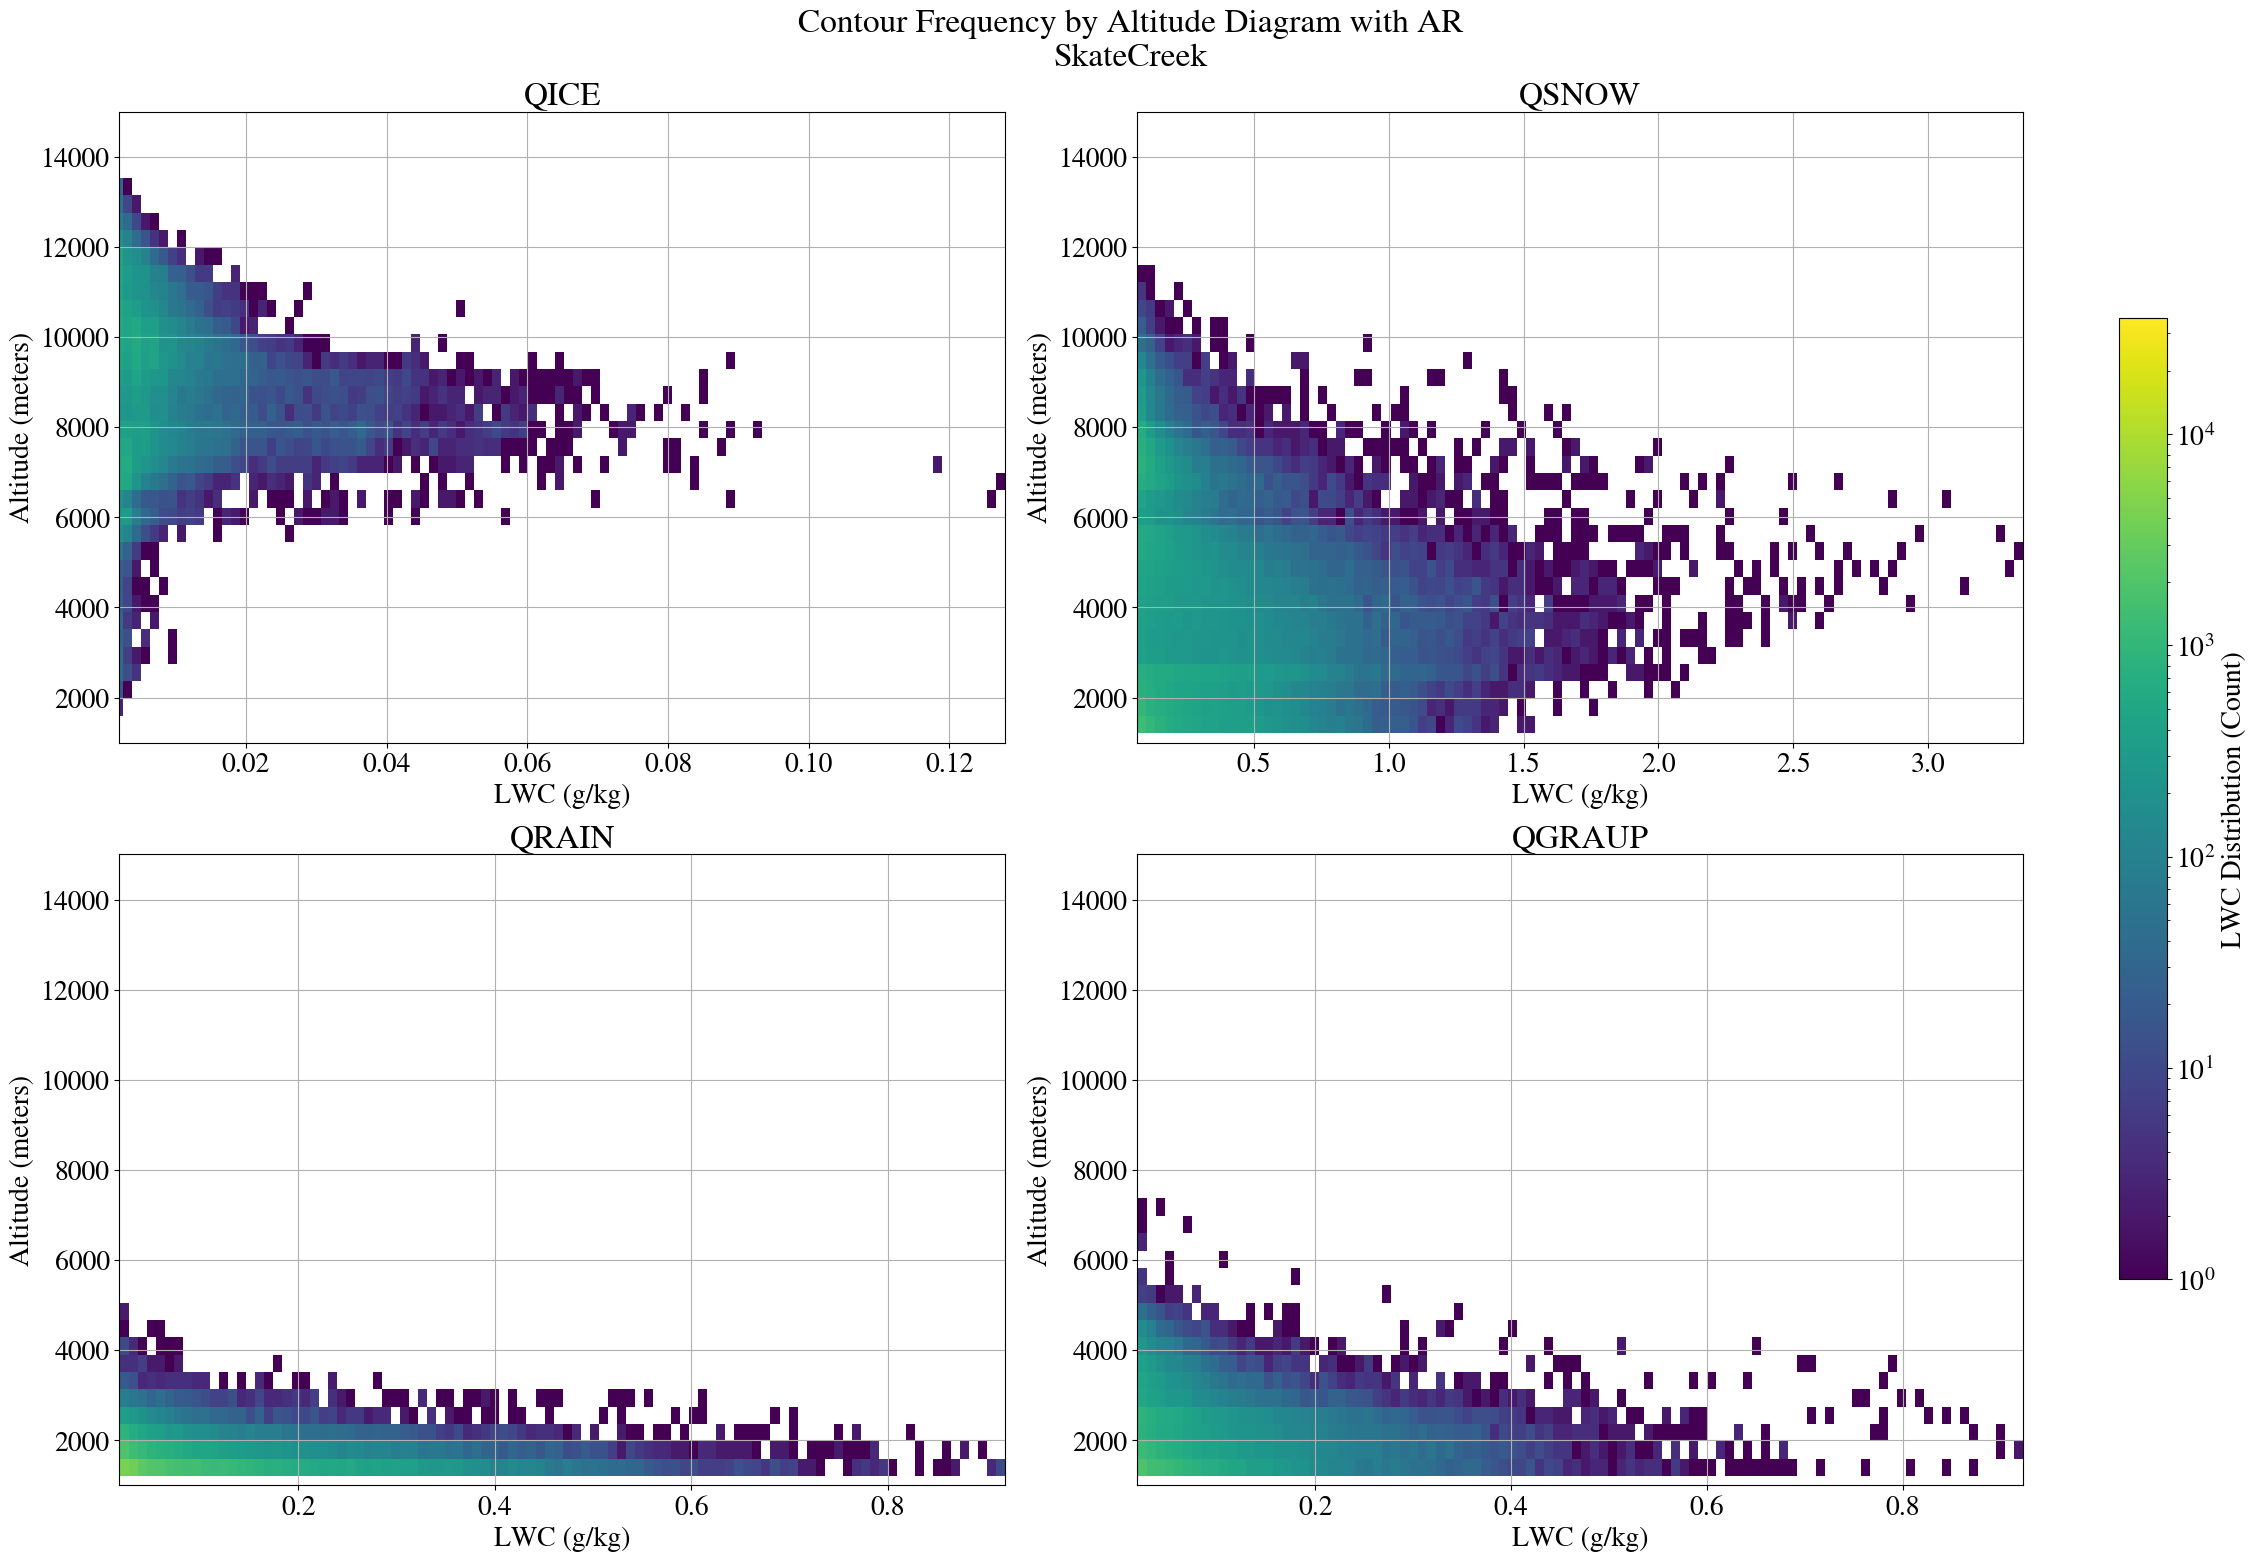

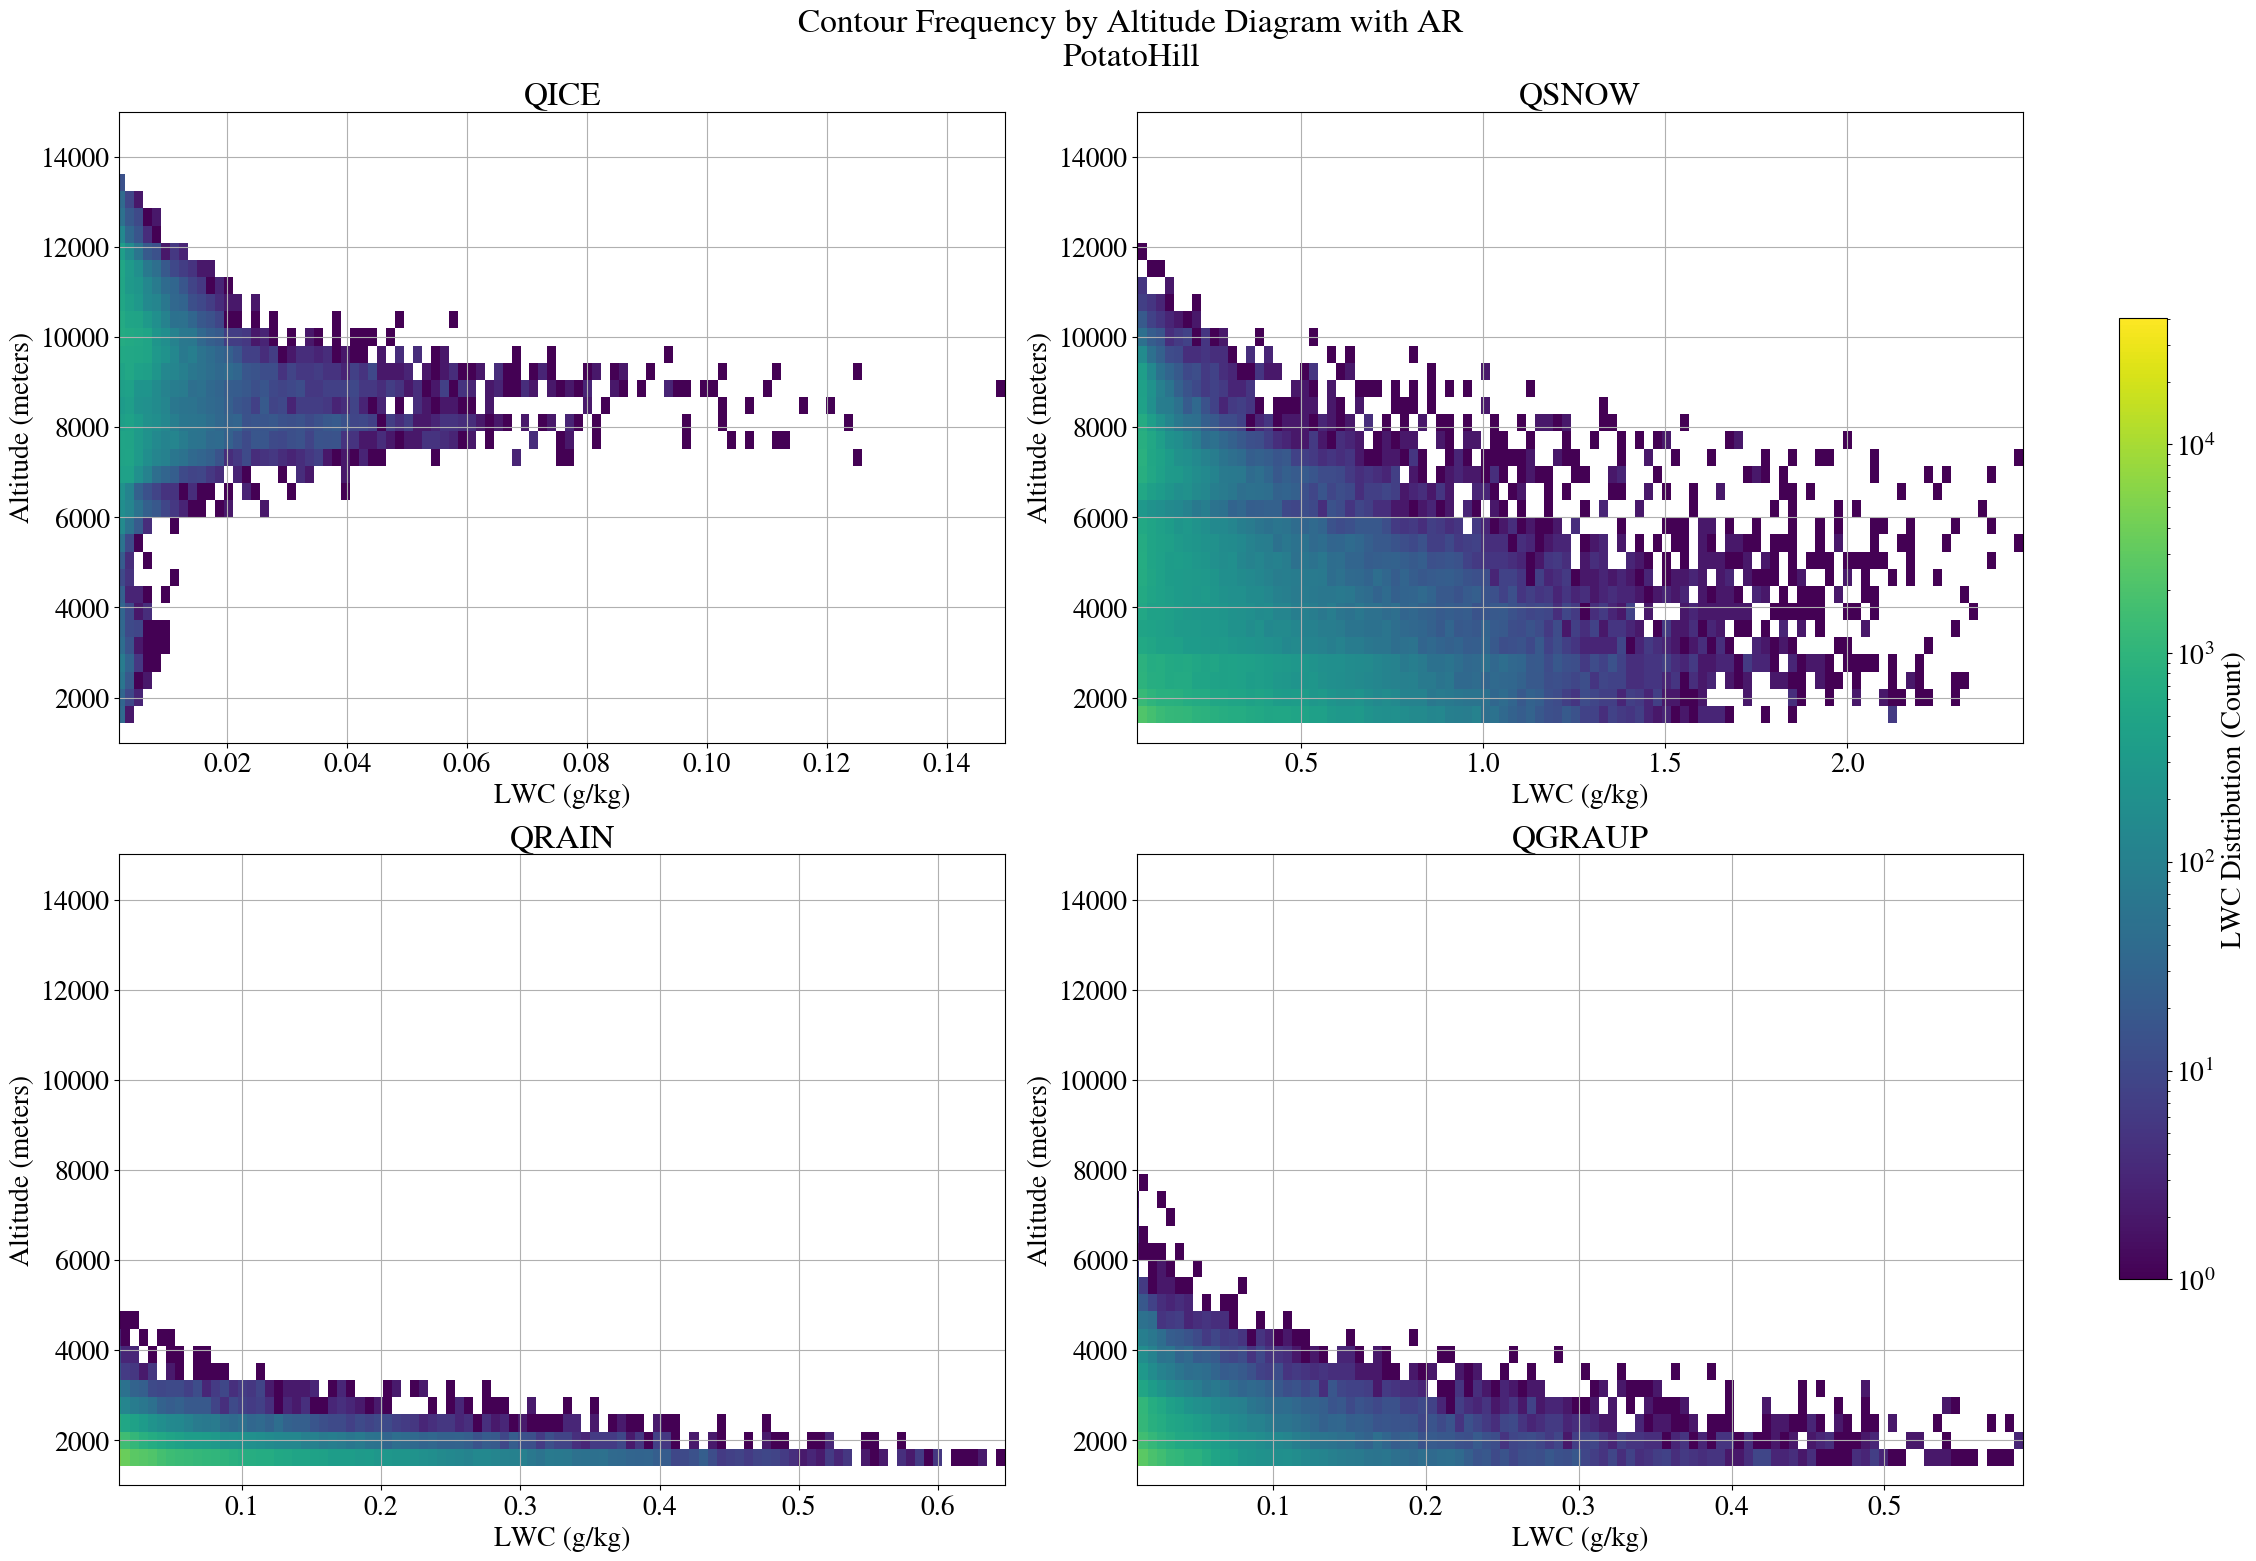

In [113]:
# dom_data=nc.Dataset(os.path.join(data_root, 'ncfiles','domain', 'wrfconstants_usgs404_roza.nc'))
dom_data=xr.open_dataset(os.path.join(data_root, 'ncfiles','domain', 'wrfconstants_usgs404_roza.nc'))
lat=dom_data.variables['XLAT'][:]
lon=dom_data.variables['XLONG'][:]
height=dom_data.variables['HGT'][:]

def plot_qvar(region):
    precip_vars=['QICE','QSNOW','QRAIN','QGRAUP']
    # _file = os.path.join(cfad_data_dir, f'q_mask_{region}.nc')
    _file = os.path.join(cfad_ar_data_dir, f'lw_T_mask_{region}.nc')
    data=xr.open_dataset(_file)
    # display(data.QICE_AR_avg)
    # display(data.Z_avg[:,1:])
    df = pd.DataFrame({
        'QICE':data.QICE_AR.values.flatten()*1e3, 
        'QSNOW':data.QSNOW_AR.values.flatten()*1e3, 
        'QRAIN':data.QRAIN_AR.values.flatten()*1e3,
        'QGRAUP':data.QGRAUP_AR.values.flatten()*1e3,
        'Z':data.Z.values.flatten()}).dropna()
    # df = pd.DataFrame({
    #     'QICE':data.QICE.values.flatten(), 
    #     'QSNOW':data.QSNOW.values.flatten(), 
    #     'QRAIN':data.QRAIN.values.flatten(),
    #     'QGRAUP':data.QGRAUP.values.flatten(),
    #     'Z':data.Z.values.flatten()}).dropna()
    fig = plt.figure(figsize=(22.5, 15.5), constrained_layout=True)
    def plot_precip_hist_subplots():
        # colors=['tab:blue','darkorange', 'turquoise', 'chartreuse']
        # fig = plt.figure(figsize=(10, 10))
        axs=[]
        for ii, var in enumerate(precip_vars):
            ax=fig.add_subplot(2,2,ii+1)
            _hist=ax.hist2d(df[var], 
                    # height,
                    df.Z, 
                    bins=(100, 50), 
                    cmin=0.2e-5, 
                    # cmap="ice",
                    norm=colors.LogNorm(),
                    )
            # var_avg=dataset[var].mean('bottom_top')*1000
            # counts, edges, patches = plt.hist(var_avg.values.ravel(), bins=1000, density=True)#, edgecolor='black')

            # for jj,_patch in enumerate(patches):
            #     _patch.set_facecolor(colors[ii])
            #     _patch.set_label(var)
            ax.grid()
            ax.set_xlabel('LWC (g/kg)')
            ax.set_ylabel('Altitude (meters)')
            ax.set_title(f'{var}')
            _max=df[var].max()
            ax.set_xlim(int((_max*1000)/50)/1000., _max)
            ax.set_ylim(1000, 15000)
            # display(f'{var=} max: {df[var].max()}')
            # ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            axs.append(ax)
            # cbar = ax.colorbar(orientation="vertical")

        # fig.suptitle('Level 1 Precipitation Variable Ranges', fontsize=16)
        # fig.colorbar(_hist[1], ax=axs, orientation='vertical', fraction=.1) 
        # cbar = plt.colorbar(_hist, orientation="vertical", ax=axs)
        fig.suptitle(f'Contour Frequency by Altitude Diagram with AR\n{region}', fontsize=24)
        fig.colorbar(_hist[3], ax=axs, label='LWC Distribution (Count)', orientation='vertical', shrink=0.7)
        # fig.tight_layout()
        fig.patch.set_facecolor('white')
        # plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        output_file=f'Season_precip_vars_Histogram_{region}.png'
        plt.savefig(os.path.join(qhist_dir, output_file))
        # plt.show()
    plot_precip_hist_subplots()
    # fig = plt.figure(figsize=(18.5, 10.5))
    # ax = plt.hist2d(df.QICE, df.Z, 
    #                 # bins=(100, 50), 
    #                 # cmin=0.2e-5, 
    #                 # cmap="ice",
    #                 norm=colors.LogNorm())
    
    # cbar = plt.colorbar(orientation="vertical")
    
    # plt.grid()
    # plt.yticks(fontsize=20)
    # plt.xticks(fontsize=20)
    # plt.xlabel('Liquid Water Content g/kg', fontsize=20)
    # plt.ylabel('Altitude (meters)', fontsize=20)
    # cbar.ax.tick_params(labelsize=16)
    # cbar.set_label("Counts",size=16)
    # fig.patch.set_facecolor('white')
    return fig
for _region in ["BumpingRidge", "CayusePass", "BlewettPass", "BurntMountain", "CorralPass", "CougarMountain", "FishLake", "GrouseCamp", "MeadowsPass", "SasseRidge", "SkateCreek", "PotatoHill"]:
    plot_qvar(_region)

# int((_max*100)/50)/100.


## Bumping Ridge

In [ ]:
bumpingridge_fig=cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_BumpingRidge.nc'), 'Bumping Ridge')
plt.show()

## Cayuse Pass

In [ ]:
cayusepass_fig=cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_CayusePass.nc'), 'Cayuse Pass')
plt.show()

## Grouse Camp

In [ ]:
grousecamp_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_GrouseCamp.nc'), 'Grouse Camp')
plt.show()

## Meadows Pass

In [ ]:
meadowspass_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_MeadowsPass.nc'), 'Meadows Pass')
plt.show()

## Sasse Ridge

In [ ]:
sasseridge_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_SasseRidge.nc'), 'Sasse Ridge')
plt.show()

In [ ]:
blewettpass_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_BlewettPass.nc'),'Blewett Pass')
plt.show()

In [ ]:
burntmountain_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_BurntMountain.nc'), 'Burnt Mountain')
plt.show()

In [ ]:
corralpass_fig = cfad('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_CorralPass.nc', 'Corral Pass')
plt.show()

In [ ]:
cougarmountain_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_CougarMountain.nc'), 'Cougar Mountain')
plt.show()

In [ ]:
fishlake_fig = cfad(xr.open_dataset('/Users/meghan/Roza/roza/data/cfads/ncfiles/lw_T_mask_FishLake.nc'), 'Fish Lake')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = np.random.rand(250, 250)

# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap
sns.heatmap(data, ax=ax)

# Set the font size for both x and y tick labels
ax.tick_params(axis='both', which='major', labelsize=24)

plt.show()

In [ ]:
plt.rcParams.update({'font.size': 20})
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(19.5, 13.5))
_cax = plt.axes((0.17, 0.05, 0.68, 0.015), anchor='C')
ax2_2 = ax2.twinx()
ax4_2 = ax4.twinx()

_hm_kwargs=dict(vmin=0, vmax=25) #, linewidth=.5)
# _annotate=True
_annotate=False

_hms=[]
_hms.append(sns.heatmap(np.random.rand(24,6)*25, ax=ax1, annot=_annotate, cmap='viridis', cbar_ax=_cax,
                        cbar_kws=dict(shrink=0.75,label='Frequency (%)',orientation='horizontal'),
                        **_hm_kwargs))
ax1.set_title('CONUS404', fontweight='bold', fontsize=22)
ax1.set_xticklabels([])
ax1.set_xticks([])
ax1.set_xlabel('')
# ax1.set_ylabel('Hour', fontsize=20, fontweight='bold')
# ax1.tick_params(axis='y', labelrotation=0)#, labelsize=20)
ax1.tick_params(axis='both', which='major', labelsize=20)

_hms.append(sns.heatmap(np.random.rand( 24, 6)*25,   ax=ax2, annot=_annotate, cmap='viridis', cbar=False, **_hm_kwargs))
ax2.set_title('PGW', fontweight='bold', fontsize=22)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
# ax1.set_ylabel('Hour', fontsize=20, fontweight='bold')
# ax2.tick_params(axis='y', labelrotation=0)#, labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2_2.yaxis.set_label_position("right")
ax2.set_xticklabels([])
ax2.set_xticks([])
ax2_2.set_ylabel('Air', labelpad=70, fontsize=22, fontweight='bold')
ax2_2.set_yticklabels([])
ax2_2.set_yticks([])
ax2_2.yaxis.label.set_rotation(0)
ax2_2.tick_params(axis='both', which='major', labelsize=20)

_hms.append(sns.heatmap(np.random.rand(24, 6)*25, ax=ax3, annot=_annotate, cmap='viridis', cbar=False, **_hm_kwargs))
# ax3.tick_params(axis='y', labelrotation=0)#, labelsize=20)
ax3.tick_params(axis='both', which='major', labelsize=20)
# ax3.set_ylabel('Hour', fontsize=20, fontweight='bold')
# ax3.set_xlabel('Month', fontsize=20, fontweight='bold')
# ax3.tick_params(axis='x', labelsize=20)

_hms.append(sns.heatmap(np.random.rand(24,6)*25,   ax=ax4, annot=_annotate, cmap='viridis', cbar=False, **_hm_kwargs))
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position("right")
# ax4.tick_params(axis='y', labelrotation=0)#, labelsize=20)
ax4.tick_params(axis='both', which='major', labelsize=20)
# ax4.set_ylabel('Hour', fontsize=20, fontweight='bold')
# ax4.set_xlabel('Month', fontsize=20, fontweight='bold')
ax4_2.yaxis.set_label_position("right")
ax4_2.set_ylabel('Ground', labelpad=105, fontsize=22, fontweight='bold')
ax4_2.set_yticklabels([])
ax4_2.set_yticks([])
ax4_2.yaxis.label.set_rotation(0)
ax4_2.tick_params(axis='both', which='major', labelsize=20)

fig.subplots_adjust(wspace=0.005, hspace=0.01)
# _cax.tick_params(labelsize=12)
# _cax.set_label('Frequency (%)', size=22)

fig.suptitle(f'Seedable Conditions Frequency Heatmap -- Month-Hour Aggregate\nRegion: criteria.name | Surface: wind.name', fontsize=26)